# FIFA 24 Player Stats — Exploratory Data Analysis

This project performs a comprehensive exploratory data analysis on the FIFA 24 
Player Statistics dataset sourced from Kaggle. The dataset contains detailed 
attributes for thousands of players including technical skills, physical traits, 
mental attributes, goalkeeper stats, and market values.

The analysis covers univariate and bivariate exploration, outlier detection, 
missing value handling, and player profiling across skill categories such as 
dribblers, strikers, elite goalkeepers, and emerging talents.

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [89]:
#Load the dataset 
df = pd.read_csv("FIFA24_PlayerStats.csv")

#Dataset contains 41 columns and they can't be loaded all together so we use this method to load them all together
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [90]:
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,att_position,interceptions,vision,composure,crossing,short_pass,long_pass,acceleration,stamina,strength,balance,sprint_speed,agility,jumping,heading,shot_power,finishing,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,73,72,68,30,65,30,50,33,64,49,41,55,86,40,52,43,51,64,54,30,31,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,58,62,70,69,70,64,54,60,63,63,64,87,81,42,67,65,65,54,60,64,68,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas Dähne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,16,27,65,17,20,49,48,14,35,18,46,38,68,41,48,36,60,17,51,14,20,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,69,71,64,48,66,29,70,44,58,53,35,73,82,56,63,57,80,67,32,24,33,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,16,28,50,10,12,38,34,11,23,20,38,28,64,24,31,34,27,13,48,4,6,9,10,16,5,61,59,62,64,64,$300.00


In [91]:
df.columns

Index(['player', 'country', 'height', 'weight', 'age', 'club', 'ball_control', 'dribbling', 'marking', 'slide_tackle', 'stand_tackle', 'aggression', 'reactions', 'att_position', 'interceptions', 'vision', 'composure', 'crossing', 'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength', 'balance', 'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'value'], dtype='object')

In [92]:
print(f'the dataset has {df.shape[0]} rows and {df.shape[1]} columns')

the dataset has 5680 rows and 41 columns


## Variable Descriptions

### Basic Info
- **player** — Name of the player.
- **country** — Nationality of the player.
- **height** — Player’s height in centimeters (cm).
- **weight** — Player’s weight in kilograms (kg).
- **age** — Player’s age in years.
- **club** — Club the player currently plays for.
- **value** — Market value of the player (e.g., $1.400.000 = 1.4 million USD).

---

### Technical & Offensive Attributes
- **ball_control** — Player’s ability to control the ball during possession.
- **dribbling** — Skill in maneuvering the ball while evading defenders.
- **crossing** — Accuracy and quality of crosses from wide areas.
- **short_pass** — Effectiveness in short-range passing.
- **long_pass** — Ability to deliver accurate long-range passes.
- **curve** — How much curve/spin the player can apply to the ball.
- **finishing** — Capability to convert shots into goals from close range.
- **volleys** — Skill in striking the ball while it’s in the air (before it touches the ground).
- **long_shots** — Proficiency in shooting accurately from long distances.
- **fk_acc** — Accuracy in taking direct free kicks.
- **penalties** — Effectiveness in taking penalty kicks.
- **shot_power** — Power behind the player’s shots.
- **att_position** — Ability to position themselves well in attacking situations.

---

### Defensive Attributes
- **marking** — Skill in closely marking and tracking opponents.
- **slide_tackle** — Effectiveness in executing slide tackles.
- **stand_tackle** — Competence in standing tackles to dispossess players.
- **interceptions** — Ability to read the game and intercept passes.

---

### Physical & Athletic Attributes
- **acceleration** — How quickly a player reaches top speed.
- **sprint_speed** — Top running speed of the player.
- **agility** — Quickness and ease of movement/change of direction.
- **stamina** — Ability to maintain performance throughout the match.
- **strength** — Physical power and ability to hold off opponents.
- **balance** — Stability and control while in motion or under pressure.
- **jumping** — Vertical leap height.
- **heading** — Accuracy and power in heading the ball.

---

### Mental Attributes
- **reactions** — Speed at which the player responds to in-game events.
- **vision** — Ability to spot and execute key passes.
- **composure** — Performance under pressure and ability to stay calm.
- **aggression** — Level of assertiveness and physical engagement.

---

### Goalkeeper-Specific Attributes
*(These are mostly relevant for goalkeepers; will be low or zero for outfield players)*
- **gk_positioning** — Ability to position correctly in goal during shots.
- **gk_diving** — Diving skill to save shots.
- **gk_handling** — Ability to catch or hold on to the ball.
- **gk_kicking** — Accuracy and power in goal kicks or distribution.
- **gk_reflexes** — Quick reaction to make close-range or sudden saves.

In [93]:
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,att_position,interceptions,vision,composure,crossing,short_pass,long_pass,acceleration,stamina,strength,balance,sprint_speed,agility,jumping,heading,shot_power,finishing,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,0.0,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000
mean,181.671831,75.283803,26.315845,58.901761,56.116373,NaN,46.732570,48.824648,56.319366,61.948768,50.710739,47.392958,54.455458,58.611268,49.780458,59.324472,53.904754,64.744366,63.369366,65.378169,64.063204,64.949648,63.770246,65.079049,52.236268,58.173063,46.339261,47.152641,48.089085,43.291373,48.163908,42.919190,16.190141,16.439789,16.194894,16.073768,16.572535
std,6.829680,6.999642,4.730292,16.560609,18.764235,NaN,20.521785,20.978541,16.847245,8.876965,19.769662,20.453887,13.696858,12.015176,17.893373,14.320748,14.600409,15.291341,16.103125,12.625184,14.492776,15.108142,14.850367,12.272221,17.355420,12.963987,19.809825,19.457000,18.080833,17.083868,15.773335,17.902821,17.149019,17.638100,16.995298,16.811196,17.944732
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,3.000000,3.000000,10.000000,13.000000,6.000000,11.000000,9.000000,12.000000,14.000000,25.000000,20.000000,13.000000,21.000000,23.000000,6.000000,20.000000,4.000000,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,40.000000,28.000000,45.000000,52.000000,39.000000,55.000000,46.000000,57.000000,56.000000,58.000000,56.000000,57.000000,56.000000,57.000000,45.000000,49.000000,31.000000,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,56.000000,54.000000,56.000000,60.000000,54.000000,63.000000,57.000000,68.000000,66.000000,66.000000,66.000000,68.000000,66.000000,66.000000,55.000000,59.000000,50.500000,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,65.000000,64.000000,65.000000,67.000000,63.000000,68.000000,64.000000,75.000000,74.000000,74.000000,74.000000,75.000000,74.000000,73.000000,64.000000,68.000000,62.000000,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,93.000000,89.000000,94.000000,96.000000,94.000000,93.000000,93.000000,97.000000,95.000000,96.000000,95.000000,97.000000,93.000000,95.000000,93.000000,94.000000,94.000000,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.000000,87.000000,90.000000,89.000000


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5680 non-null   object 
 1   country         5680 non-null   object 
 2   height          5680 non-null   int64  
 3   weight          5680 non-null   int64  
 4   age             5680 non-null   int64  
 5   club            5680 non-null   object 
 6   ball_control    5680 non-null   int64  
 7   dribbling       5680 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5680 non-null   int64  
 10  stand_tackle    5680 non-null   int64  
 11  aggression      5680 non-null   int64  
 12  reactions       5680 non-null   int64  
 13  att_position    5680 non-null   int64  
 14  interceptions   5680 non-null   int64  
 15  vision          5680 non-null   int64  
 16  composure       5680 non-null   int64  
 17  crossing        5680 non-null   i

In [95]:
#Check for datatypes  
df.dtypes

player             object
country            object
height              int64
weight              int64
age                 int64
club               object
ball_control        int64
dribbling           int64
marking           float64
slide_tackle        int64
stand_tackle        int64
aggression          int64
reactions           int64
att_position        int64
interceptions       int64
vision              int64
composure           int64
crossing            int64
short_pass          int64
long_pass           int64
acceleration        int64
stamina             int64
strength            int64
balance             int64
sprint_speed        int64
agility             int64
jumping             int64
heading             int64
shot_power          int64
finishing           int64
long_shots          int64
curve               int64
fk_acc              int64
penalties           int64
volleys             int64
gk_positioning      int64
gk_diving           int64
gk_handling         int64
gk_kicking  

In [96]:
#Check for Null Values
df.isnull().sum()

player               0
country              0
height               0
weight               0
age                  0
club                 0
ball_control         0
dribbling            0
marking           5680
slide_tackle         0
stand_tackle         0
aggression           0
reactions            0
att_position         0
interceptions        0
vision               0
composure            0
crossing             0
short_pass           0
long_pass            0
acceleration         0
stamina              0
strength             0
balance              0
sprint_speed         0
agility              0
jumping              0
heading              0
shot_power           0
finishing            0
long_shots           0
curve                0
fk_acc               0
penalties            0
volleys              0
gk_positioning       0
gk_diving            0
gk_handling          0
gk_kicking           0
gk_reflexes          0
value                0
dtype: int64

we'll have to just drop or engineer the **marking** column other columns are free of null values

In [97]:
print("% of Null values in marking column")
(df['marking'].isnull().mean()*100)

% of Null values in marking column


np.float64(100.0)

# Univariate Analysis

In this section we analyze each feature individually to understand its distribution, 
frequency, and overall behavior. Univariate analysis helps us identify trends, 
outliers, and potential data quality issues before diving deeper.

We categorize features into two types:

### 1. Categorical Features
Non-numeric columns such as player name, country, and club — analyzed using 
`countplot` and `barplot` to see how frequently each category appears.

### 2. Numerical Features
Continuous or discrete numeric values such as age, height, weight, and skill 
ratings — analyzed using `histplot` and `boxplot` to understand distribution, 
range, and potential outliers analysis.


### Get the numerical and categorical columns 


In [98]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical Columns {categorical_cols}\n\nNumerical columns {numerical_cols}')

Categorical Columns ['player', 'country', 'club', 'value']

Numerical columns ['height', 'weight', 'age', 'ball_control', 'dribbling', 'marking', 'slide_tackle', 'stand_tackle', 'aggression', 'reactions', 'att_position', 'interceptions', 'vision', 'composure', 'crossing', 'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength', 'balance', 'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes']


## Categorical Univariate:
- we'll only plot top 20's for each categorical column because it'll be less insightful if we draw all 5000 rows

### Top 20 Players by Appearance Frequency

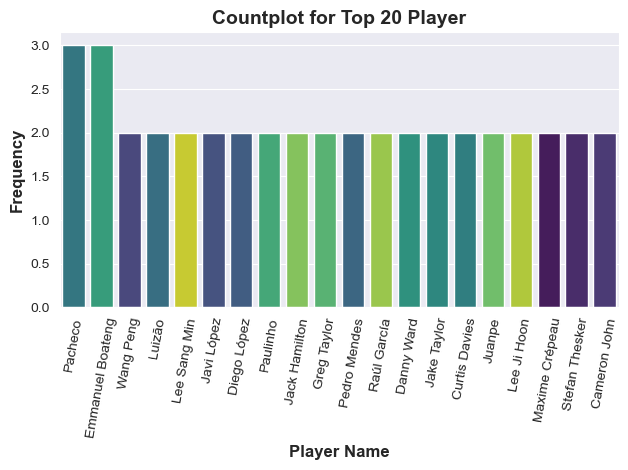

In [99]:
sns.set_style("darkgrid")
top_20 = df['player'].value_counts().nlargest(20).index
filtered_df = df[df['player'].isin(top_20)]
sns.countplot(data=filtered_df, x='player', order=top_20,legend=False,hue='player',palette='viridis')
plt.xlabel('Player Name',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Player',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

**Insight:** **Emmanuel Boateng** and **Pacheco** appear multiple times in the dataset, suggesting either duplicate entries or multiple records due to club transfers or position variations. The rest of the player names show a consistent, non-repetitive distribution, indicating unique entries.

### Top 20 Countries by Player Count

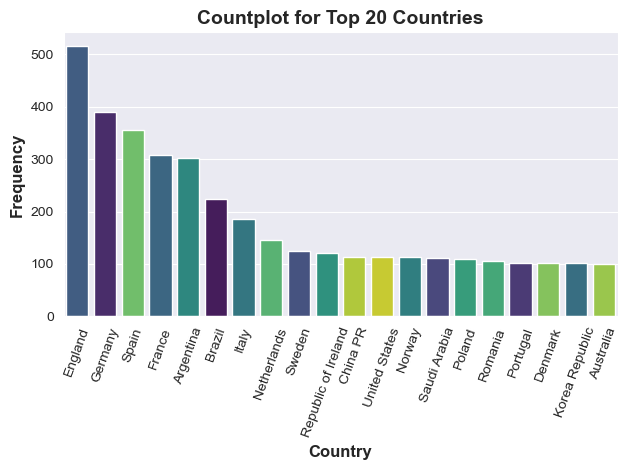

In [100]:
sns.set_style("darkgrid")
top_20 = df['country'].value_counts().nlargest(20).index
filtered_df = df[df['country'].isin(top_20)]
sns.countplot(data=filtered_df, x='country', order=top_20,legend=False,hue='country',palette='viridis')
plt.xlabel('Country',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Countries',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

**insight:** **England** tops the chart as the country with the highest number of players in the dataset, indicating a strong representation of English talent in FIFA24. It is followed closely by **Germany** and **Spain**, both of which also contribute significantly to the global player pool.

### Top 20 Clubs by Player Count

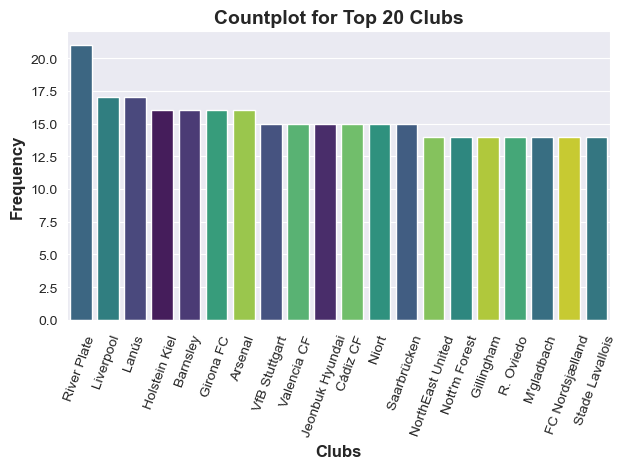

In [101]:
sns.set_style("darkgrid")
top_20 = df['club'].value_counts().nlargest(20).index
filtered_df = df[df['club'].isin(top_20)]
sns.countplot(data=filtered_df, x='club', order=top_20,legend=False,hue='club',palette='viridis')
plt.xlabel('Clubs',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Clubs',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

**Insight:** River Plate leads as the club with the most players in the dataset, 
followed by Liverpool and Lanús Football Club. The presence of both European giants 
and South American clubs in the top 20 reflects the global diversity of FIFA 24's 
player pool.

## Numerical Univariate Analysis

In this stage, we explored the distribution of numerical features in the dataset. Rather than visualizing all numerical columns, we selectively analyzed 6–7 key attributes to keep the analysis focused, meaningful, and easy to interpret.

The selected features were chosen based on their relevance to player performance, physical attributes, and market value. These include:

- Age
- Height
- Ball Control
- Sprint Speed
- Strength
- Goalkeeper Reflexes

Histograms were used to visualize the distribution of each selected feature. Key takeaways and observations were noted to better understand player demographics and characteristics. The remaining numerical features were scanned during initial exploration but omitted from visual plots to maintain readability and avoid unnecessary repetition.


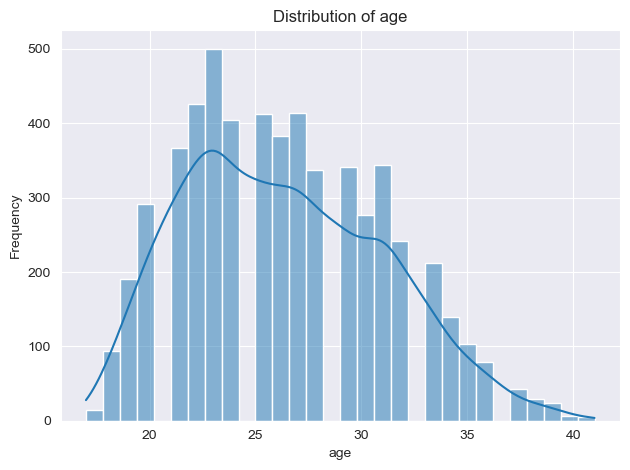

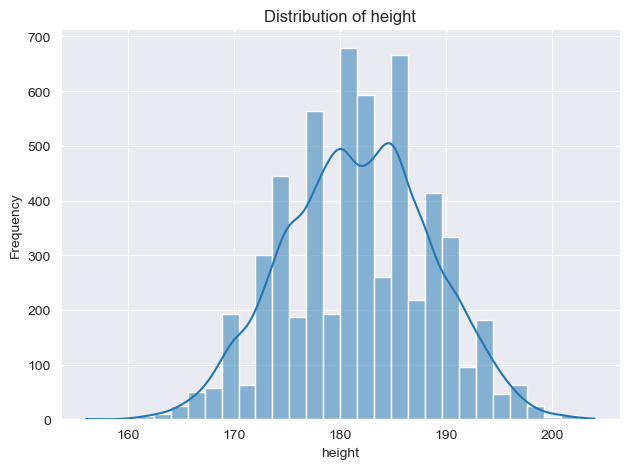

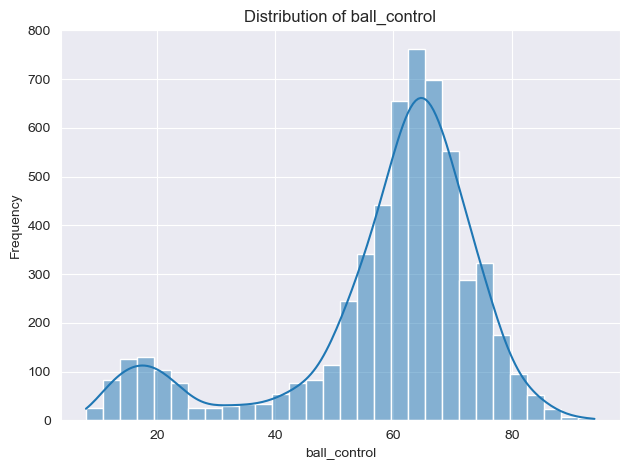

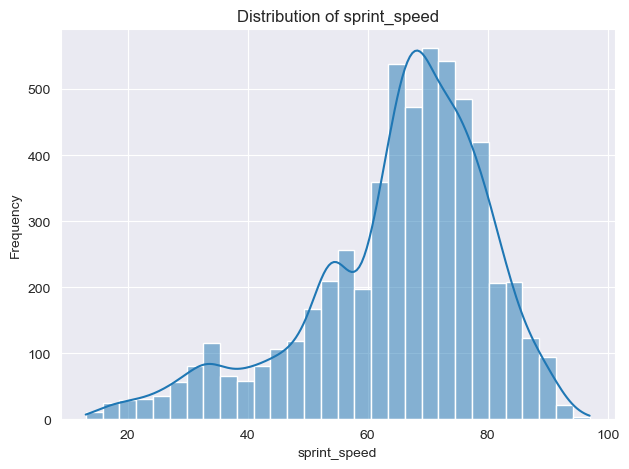

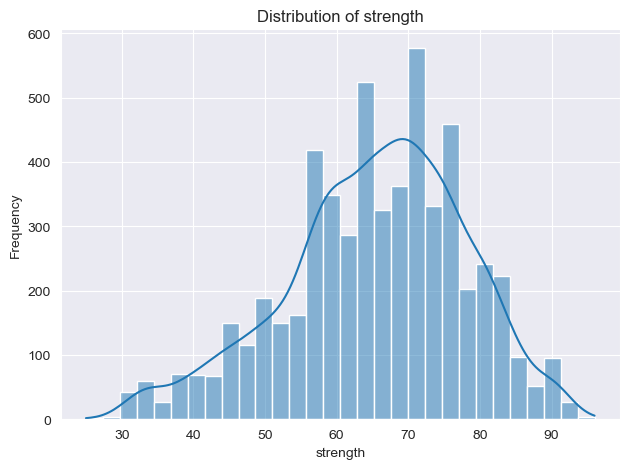

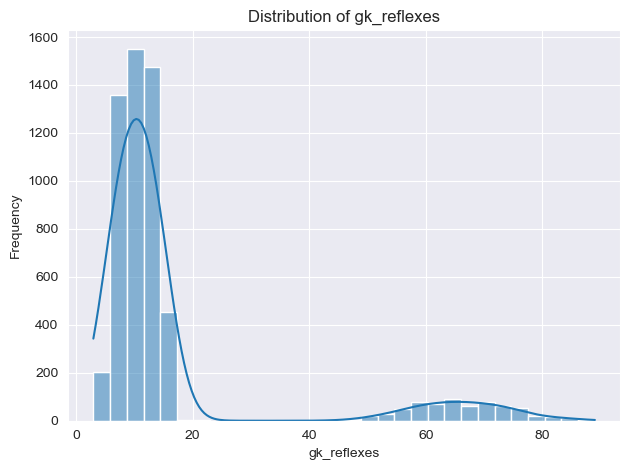

In [102]:
def plot_numerical(feature):
    sns.set_style("darkgrid")
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

features_to_plot = ['age', 'height', 'ball_control', 'sprint_speed', 'strength', 'gk_reflexes']

for col in features_to_plot:
    plot_numerical(col)

**Insights from Numerical Univariate Analysis:**

- **Age** — Right skewed distribution peaking around 23–24, indicating most FIFA 24 
players are young with few veterans extending the tail toward 40.
- **Height** — Near-normal with a slight bimodal pattern around 181–185cm, 
suggesting two player groups — shorter outfield players and taller defenders/goalkeepers.
- **Ball Control** — Bimodal distribution with a small peak near 15–20 and a main 
peak around 60–65, reflecting the clear separation between goalkeepers and outfield players.
- **Sprint Speed** — Bimodal pattern for the same reason, with goalkeepers clustering 
around 35–40 and outfield players peaking near 65–70.
- **Strength** — Roughly normal distribution centered around 68–72, suggesting most 
players have moderate to high physical strength regardless of position.
- **GK Reflexes** — Most striking distribution — a dominant spike near 5–15 for 
outfield players and a separate cluster at 60–80 for actual goalkeepers, clearly 
separating the two groups.ade.


# Handling Outliers

In this stage, we'll check for the presence of outliers in key numerical columns.

- If outliers are found, we will handle them accordingly.
- If no significant outliers are detected, we will move on to the next stage.

**Technique Used:**  
We will use the **IQR (Interquartile Range)** method to detect and handle outliers.

To avoid overwhelming visuals, we applied the IQR method across all numerical columns programmatically.

We then selected a few columns for visualization based on the number of detected outliers and relevance.

This ensures clean analysis while maintaining code readability.

In [103]:
df.describe() # Checking for potential outliers in the dataset

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,att_position,interceptions,vision,composure,crossing,short_pass,long_pass,acceleration,stamina,strength,balance,sprint_speed,agility,jumping,heading,shot_power,finishing,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,0.0,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000
mean,181.671831,75.283803,26.315845,58.901761,56.116373,NaN,46.732570,48.824648,56.319366,61.948768,50.710739,47.392958,54.455458,58.611268,49.780458,59.324472,53.904754,64.744366,63.369366,65.378169,64.063204,64.949648,63.770246,65.079049,52.236268,58.173063,46.339261,47.152641,48.089085,43.291373,48.163908,42.919190,16.190141,16.439789,16.194894,16.073768,16.572535
std,6.829680,6.999642,4.730292,16.560609,18.764235,NaN,20.521785,20.978541,16.847245,8.876965,19.769662,20.453887,13.696858,12.015176,17.893373,14.320748,14.600409,15.291341,16.103125,12.625184,14.492776,15.108142,14.850367,12.272221,17.355420,12.963987,19.809825,19.457000,18.080833,17.083868,15.773335,17.902821,17.149019,17.638100,16.995298,16.811196,17.944732
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,3.000000,3.000000,10.000000,13.000000,6.000000,11.000000,9.000000,12.000000,14.000000,25.000000,20.000000,13.000000,21.000000,23.000000,6.000000,20.000000,4.000000,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,40.000000,28.000000,45.000000,52.000000,39.000000,55.000000,46.000000,57.000000,56.000000,58.000000,56.000000,57.000000,56.000000,57.000000,45.000000,49.000000,31.000000,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,56.000000,54.000000,56.000000,60.000000,54.000000,63.000000,57.000000,68.000000,66.000000,66.000000,66.000000,68.000000,66.000000,66.000000,55.000000,59.000000,50.500000,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,65.000000,64.000000,65.000000,67.000000,63.000000,68.000000,64.000000,75.000000,74.000000,74.000000,74.000000,75.000000,74.000000,73.000000,64.000000,68.000000,62.000000,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,93.000000,89.000000,94.000000,96.000000,94.000000,93.000000,93.000000,97.000000,95.000000,96.000000,95.000000,97.000000,93.000000,95.000000,93.000000,94.000000,94.000000,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.000000,87.000000,90.000000,89.000000


**Insight:** The describe table reveals potential outliers across several columns. 
The most significant is the `value` column — where 75% of players are valued around 
€1.6M but the maximum reaches €153.5M, indicating a small group of elite players 
skewing the distribution heavily upward.

Several GK-specific columns such as `gk_reflexes`, `gk_diving`, and `gk_handling` 
show extremely low minimums near 2–8, which are not true outliers but rather outfield 
players who naturally have near-zero goalkeeper attributes. These reflect two distinct 
player populations in the dataset rather than data errors.

Columns like `ball_control` and `dribbling` show similar patterns — low minimums 
caused by goalkeepers, not actual data issues. These will be considered during 
outlier handling in the next step.

In [104]:
def detect_outliers_iqr(df, cols):
    outlier_info = []

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        if not outliers.empty:
            outlier_info.append({
                'column': col,
                'outlier_count': outliers.shape[0],
                'total': df.shape[0],
                'percent_outliers': round((outliers.shape[0] / df.shape[0]) * 100, 2)
            })

    return pd.DataFrame(outlier_info).sort_values(by='percent_outliers', ascending=False)

iqr_outliers_df = detect_outliers_iqr(df, numerical_cols)

**Outlier Detection:** The IQR analysis detected potential outliers across several 
columns. Before making any decisions, we visualize the physical columns — `weight`, 
`height`, and `age` — using boxplots to confirm whether these outliers are genuine 
data errors or legitimate real-world values.

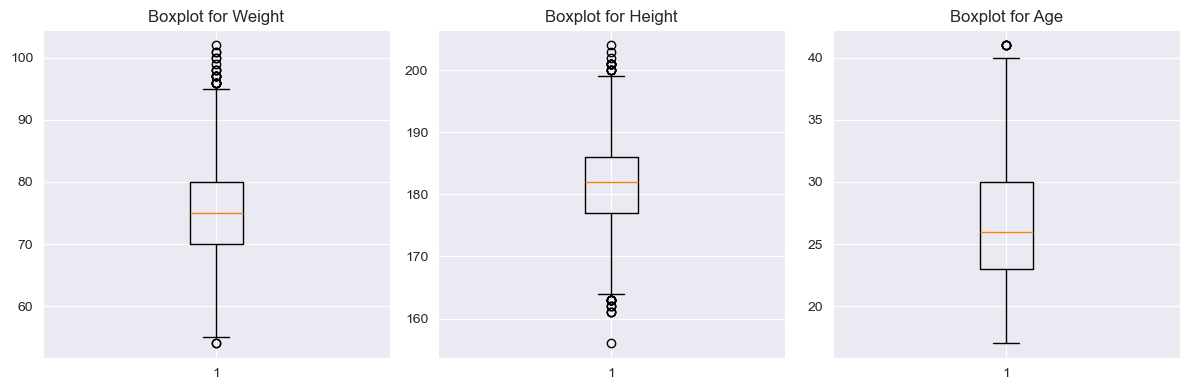

In [105]:
# Final check for outliers using boxplot 
sns.set_style('darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("Boxplot for Weight")
axes[0].boxplot(df['weight'])

axes[1].set_title("Boxplot for Height")
axes[1].boxplot(df['height'])

axes[2].set_title("Boxplot for Age")
axes[2].boxplot(df['age'])

plt.tight_layout()
plt.show()

**Weight**:  
- We've one lower outlier in weight and few upper outliers too.  

**Height**:  
- We've few lower outliers in height as you can compare it with the table above and few upper outliers too.  

**Age**:  
- We've just one upper outlier in age and no lower outliers.  

The values can be verified by using the table of outliers shown below.


In [106]:
iqr_outliers_df

,column,outlier_count,total,percent_outliers
4,dribbling,657,5680,11.57
25,gk_reflexes,633,5680,11.14
24,gk_kicking,633,5680,11.14
23,gk_handling,633,5680,11.14
22,gk_diving,633,5680,11.14
21,gk_positioning,633,5680,11.14
3,ball_control,628,5680,11.06
8,short_pass,571,5680,10.05
17,heading,529,5680,9.31
11,stamina,316,5680,5.56


In [107]:
print("Before:", df.shape)

cols_to_clean = ['height', 'weight', 'age']

for col in cols_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After:", df.shape)

Before: (5680, 41)
After: (5625, 41)


**Insight:** After applying the IQR method across numerical columns and visualizing 
with boxplots, we made a deliberate decision not to drop any outliers for the 
following reasons:

- **Physical columns (height, weight, age):** The few extreme values detected are 
legitimate real-world data points — a 41 year old veteran, an unusually tall 
goalkeeper, or a heavy defender. These are not data errors.

- **Skill columns (ball_control, dribbling, gk_reflexes etc.):** Low values in 
these columns belong to goalkeepers who naturally have near-zero outfield skill 
ratings, and near-zero GK stats belong to outfield players. These are not outliers 
— they reflect two distinct player populations in one dataset. Removing them would 
mean losing an entire position group from the analysis.

- **Value column:** Elite players like Mbappe at €153M are real and analytically 
valuable. Dropping them would remove the most interesting data points from any 
market value analysis.

The dataset shape remains unchanged and we proceed with the full dataset intact.

# Handling Missing Values and Data Transformation

- Handle missing values using techniques like `fillna()`, `dropna()`, and `replace()`.
- Transform column values such as `club` and `value` for consistency, analysis and other columns if found 

### `Marking` NaN values Handling 
only marking column has NaN values marking column is basically the defensive ability so we'll use some attributes of player to fill this column instead of dropping it

In [108]:
df['marking'] = df['marking'].fillna(
    df[['slide_tackle', 'stand_tackle', 'interceptions', 'aggression', 'strength']].mean(axis=1)
)

**Insight:** The `marking` column was the only column with missing values. Instead 
of filling with the column mean — which would give every player the same value 
regardless of their actual ability — we filled each missing value using the average 
of that specific player's own defensive attributes: `slide_tackle`, `stand_tackle`, 
`interceptions`, `aggression`, and `strength`.

These columns were chosen because marking is fundamentally a defensive skill — a 
player who tackles well, intercepts effectively and plays aggressively is likely to 
also mark well. This approach gives a personalized estimate per player rather than 
a blanket average, making it more accurate and analytically sound.

In [109]:
df.isna().sum()
#Missing value Cleaned/filled 

player            0
country           0
height            0
weight            0
age               0
club              0
ball_control      0
dribbling         0
marking           0
slide_tackle      0
stand_tackle      0
aggression        0
reactions         0
att_position      0
interceptions     0
vision            0
composure         0
crossing          0
short_pass        0
long_pass         0
acceleration      0
stamina           0
strength          0
balance           0
sprint_speed      0
agility           0
jumping           0
heading           0
shot_power        0
finishing         0
long_shots        0
curve             0
fk_acc            0
penalties         0
volleys           0
gk_positioning    0
gk_diving         0
gk_handling       0
gk_kicking        0
gk_reflexes       0
value             0
dtype: int64

### Data Transformation
- In this step, we'll identify and fix inconsistent or improperly formatted data. This includes:
 - Handling string values that contain inconsistent formats (e.g., extra spaces, mixed cases, currency symbols).
 - Transforming text-based columns like club and value to ensure uniformity and enable further analysis.

- Example: Converting value from strings like "€1.2M" to numeric float values like 1200000.0.
 - Cleaning club names by removing unwanted characters or fixing capitalization issues.

In [110]:
def parse_value(val):
    val = str(val).replace('$', '').strip()
    
    if val.count('.') > 1:
        val = val.replace('.', '') 
    
    return float(val)

df['value'] = df['value'].apply(parse_value)

In [111]:
# Remove accents and unify spellings 
df['player'] = df['player'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

`Values` are transformed by removing the $ symbol! and marking is filled by combining two columns and accent for different players removed

# Grouping and Visualizing Columns  
In this notebook, we explore relationships between key columns using groupings and visualizations.  
We'll use plots like bar charts, count plots, and more to uncover insights.  
Grouping helps us spot trends and patterns hidden in raw data.


# Grouping Overview

 ## Skill Groups  
### Technical  
- **Dribblers**: Elite ball carriers with close control and agility  
- **Pass Masters**: Midfield maestros with visionary distribution  

### Defensive  
- **Ball-Winners**: Tenacious tacklers who dominate duels  
- **Silent Destroyers**: Intelligent interceptors with calm under pressure  

### Attacking  
- **Strikers**: Clinical finishers with positional awareness  
- **Long-Shooters**: Specialists in powerful distance strikes  

### Goalkeeping  
- **Elite GKs**: Complete shot-stoppers with strong distribution  
- **Penalty Stoppers**: Reflex specialists with commanding presence  

## Physical Profiles  
- **Dominant CBs**: Aerial powerhouses with physicality  
- **Explosive Wingers**: Pace-driven attackers with endurance  
- **Emerging Talents**: High-potential youngsters with technical foundation  
- **Set-Piece Experts**: Dead-ball specialists with precision  

## Hidden Gems  
- **Complete Players**: Well-rounded bargains with no weaknesses  75 all key stats + value <€20M75 all key stats + value <€20M

## Skill Groups

### Dribbler

In [112]:
#Dribblers
top_dribblers = (
    df[df['dribbling'] >= 90]  
    .sort_values(['dribbling', 'balance', 'agility'], ascending=False)
    .head(10)
    [['player', 'club', 'dribbling', 'balance', 'agility']]
)
top_dribblers

,player,club,dribbling,balance,agility
3555,Lionel Messi,Paris SG,95,95,91
5677,Neymar Jr,Paris SG,95,82,93
5229,Kylian Mbappe,Paris SG,93,81,93
3120,Marco Verratti,Paris SG,91,93,90
3628,Angel Di Maria,Juventus,90,75,91


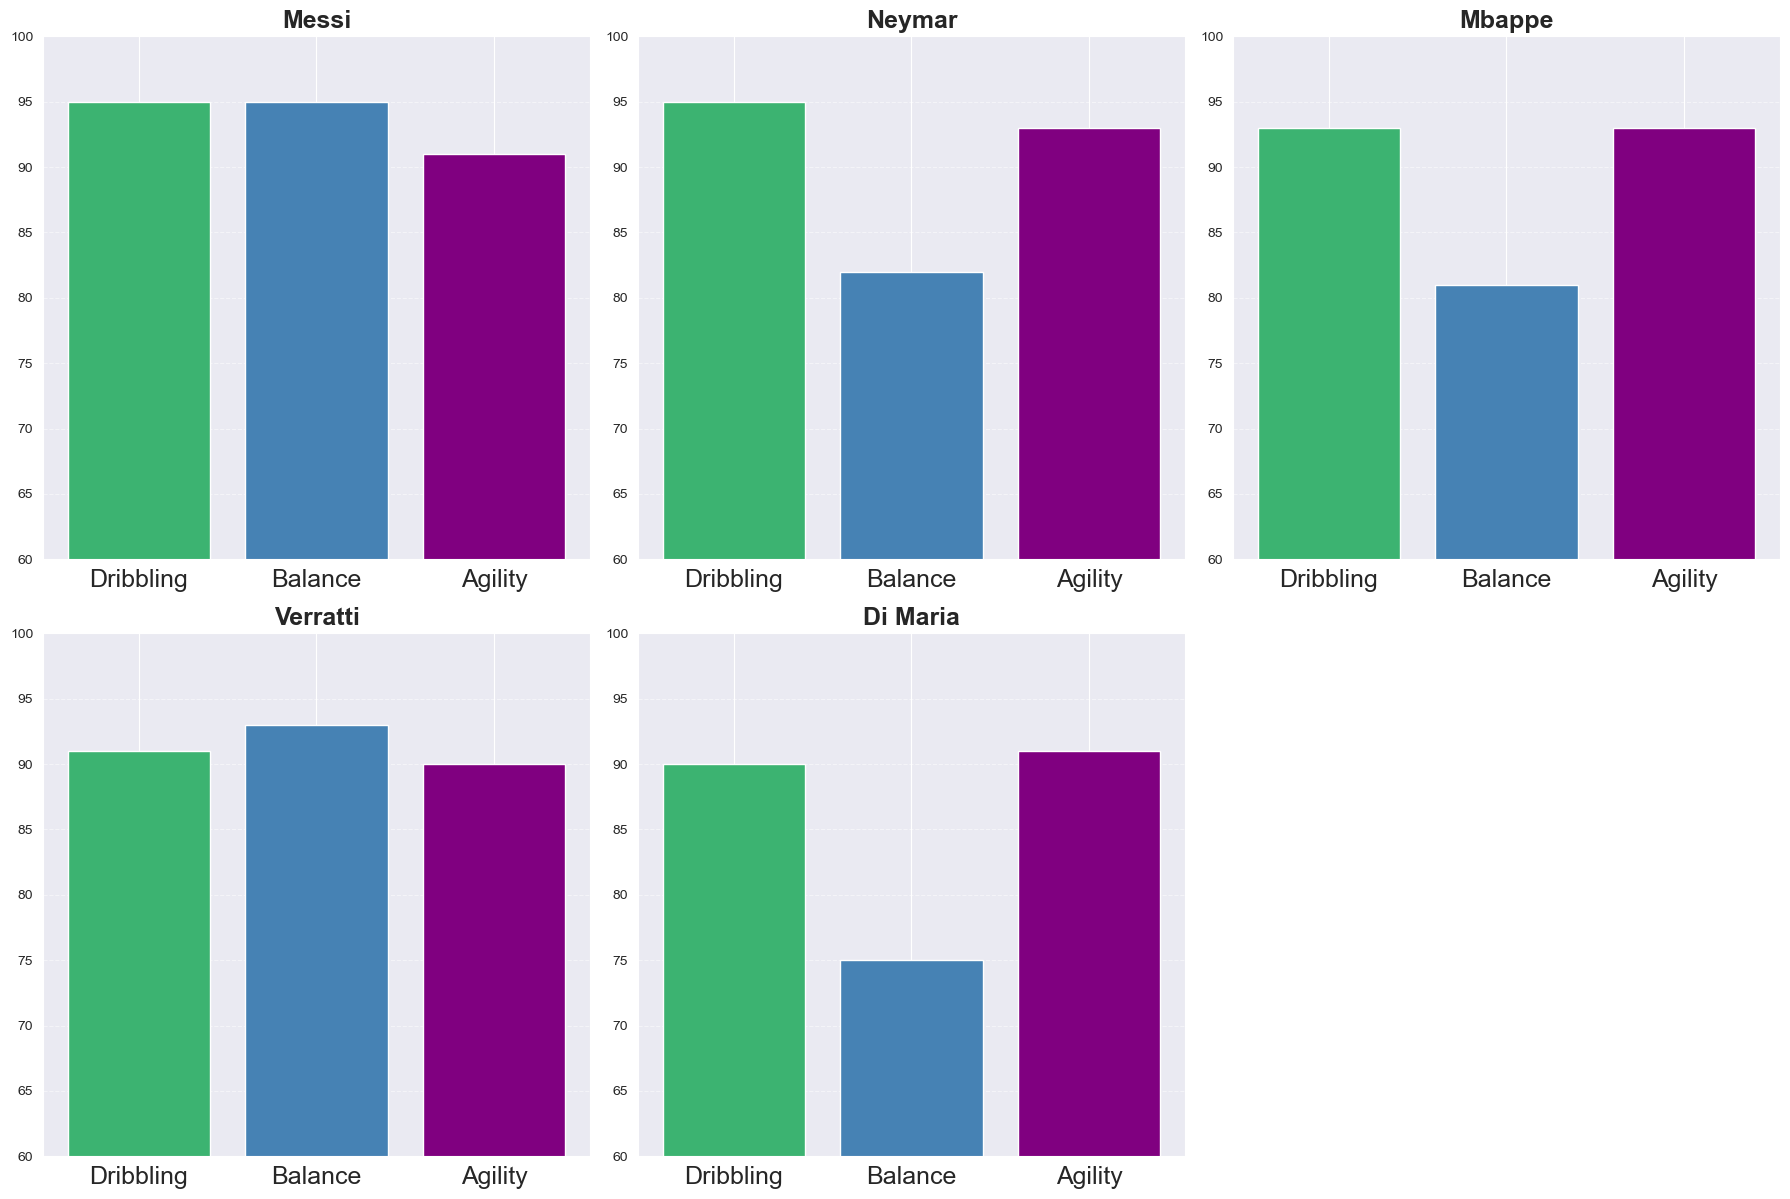

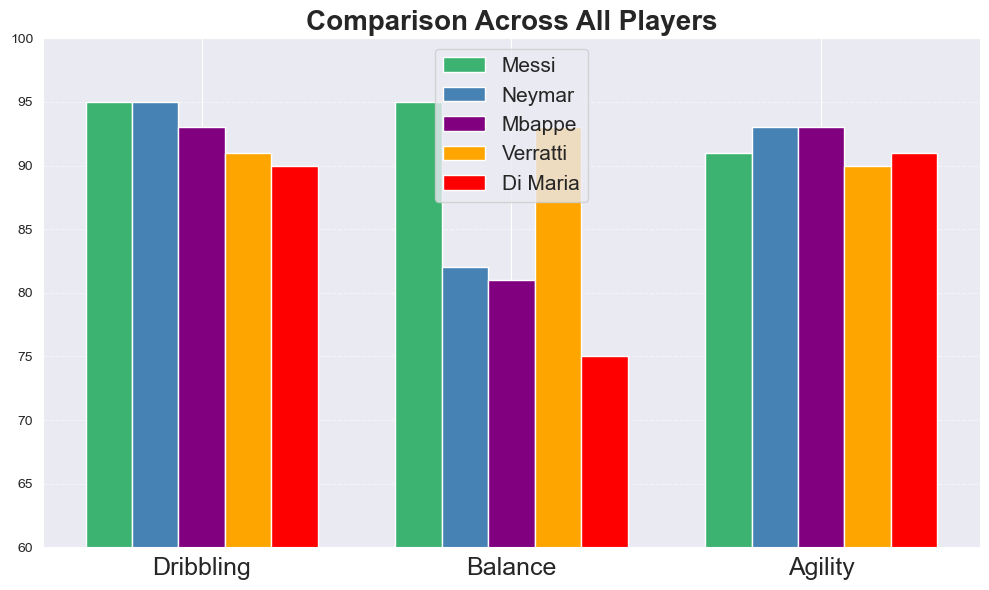

In [113]:
dribblers = {
    'Messi': [95, 95, 91],
    'Neymar': [95, 82, 93],
    'Mbappe': [93, 81, 93],
    'Verratti': [91, 93, 90],
    'Di Maria': [90, 75, 91]
}

dribble_attributes = ['Dribbling', 'Balance', 'Agility']

player_names = list(dribblers.keys())
data = np.array(list(dribblers.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 13))
axs = axs.flatten()

for i, (player, stats) in enumerate(dribblers.items()):
    axs[i].bar(dribble_attributes, stats, color=['mediumseagreen', 'steelblue', 'purple'])
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_ylim(60, 100)
    axs[i].set_xticks(range(len(dribble_attributes)))
    axs[i].set_xticklabels(dribble_attributes, fontsize=18)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(dribblers), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(dribble_attributes))
width = 0.15
colors = ['mediumseagreen', 'steelblue', 'purple', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(player_names)):
    ax.bar(x + i*width, data[i], width, label=player_names[i], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(dribble_attributes, fontsize=18)
ax.set_ylim(60, 100)
ax.set_title('Comparison Across All Players', fontsize=20, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Messi leads the dribbling category with near-perfect scores across 
all three attributes — dribbling, balance and agility all above 91. Neymar and 
Mbappe share similar dribbling and agility levels but Mbappe's balance is notably 
lower at 81, suggesting he relies more on pace than body control when beating 
defenders. Verratti stands out as an unexpected elite dribbler — his high balance 
and agility make him effective in tight spaces despite not being a traditional 
winger. Di Maria shows the weakest balance of the group at 75, compensating with 
strong agility and dribbling.

### Pass Masters 

In [114]:
top_pass = df[
    (df['vision'] >= 85) &
    (df['short_pass'] >= 85) & 
    (df['composure'] >= 85) & 
    (df['long_pass'] >= 80)    
][['player', 'club', 'vision', 'short_pass', 'long_pass', 'composure']] \
.sort_values(['vision', 'composure'], ascending=False) \
.head(5)
top_pass

,player,club,vision,short_pass,long_pass,composure
3555,Lionel Messi,Paris SG,94,91,90,96
4849,Kevin De Bruyne,Manchester City,94,93,93,88
5677,Neymar Jr,Paris SG,90,85,81,93
635,Paul Pogba,Juventus,90,87,92,85
949,Parejo,Villarreal CF,90,92,90,85


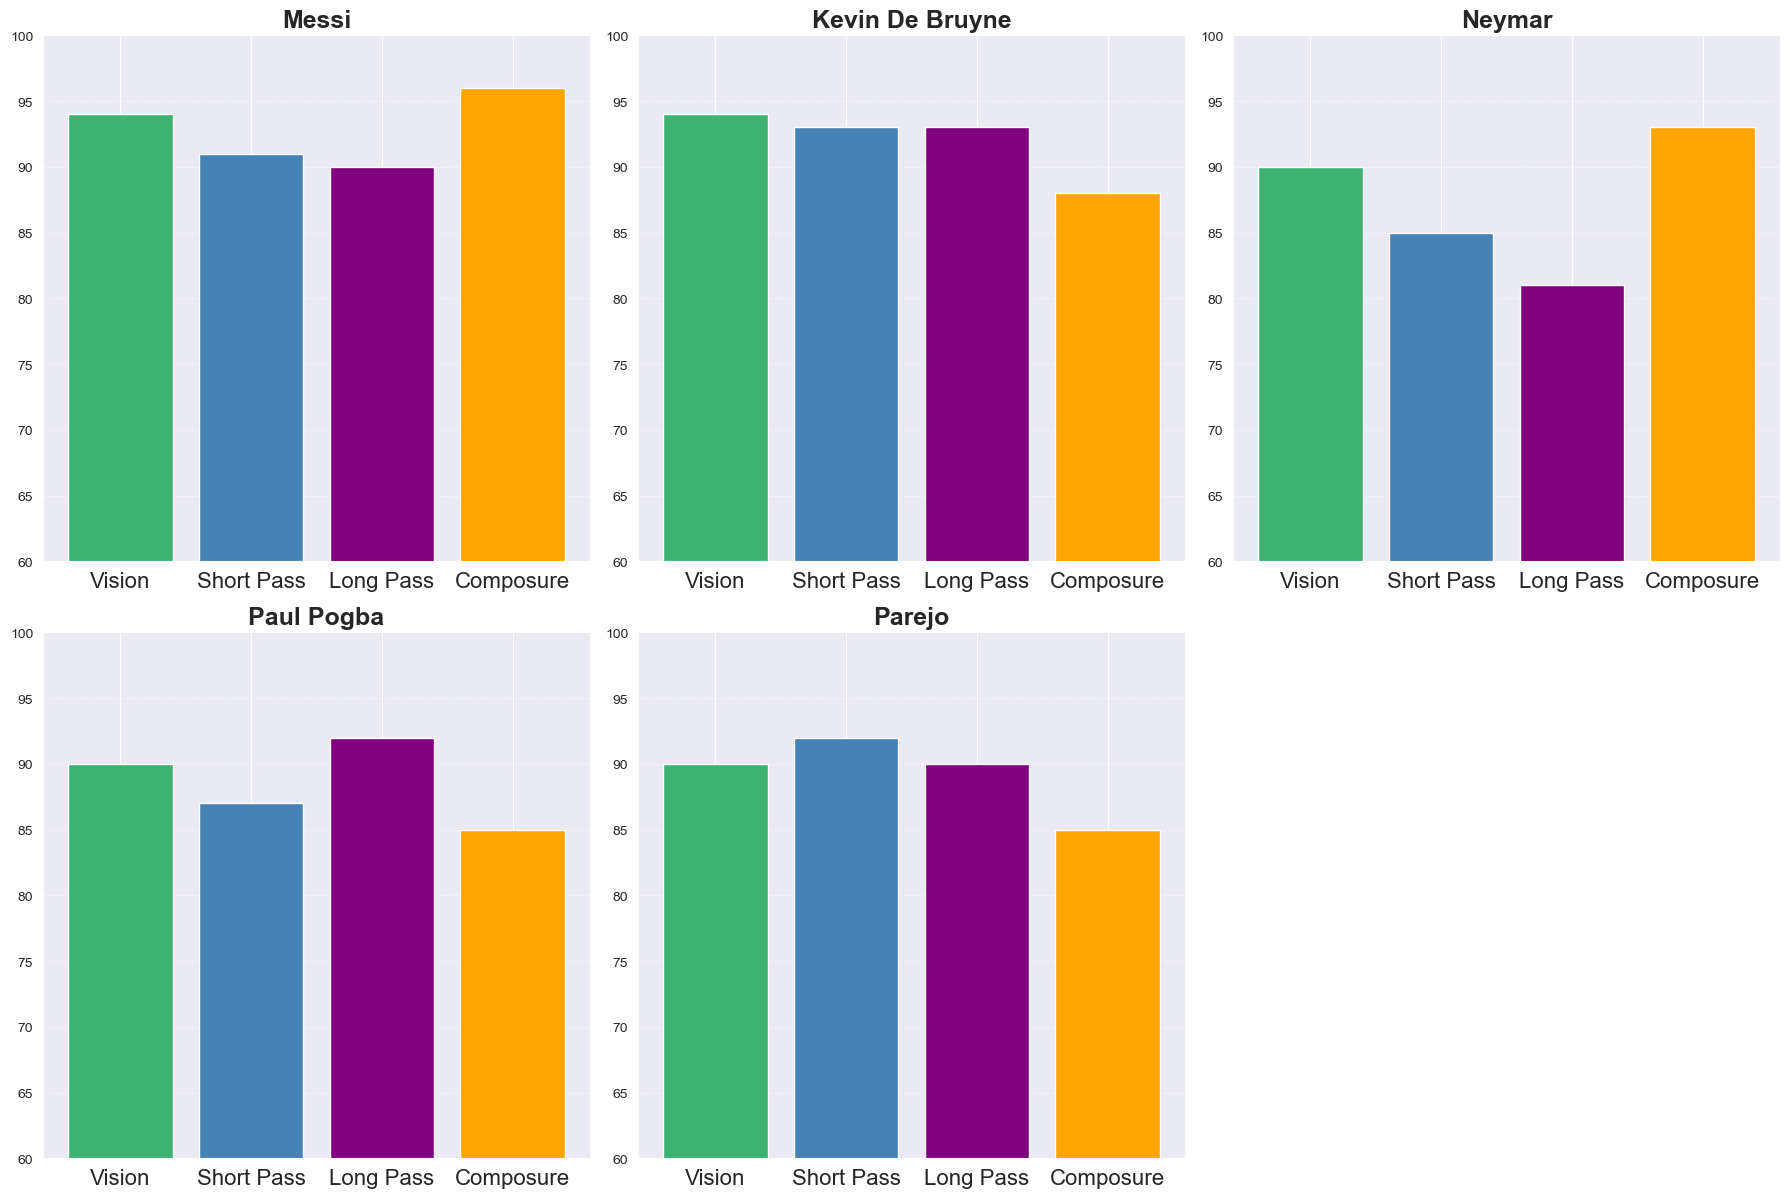

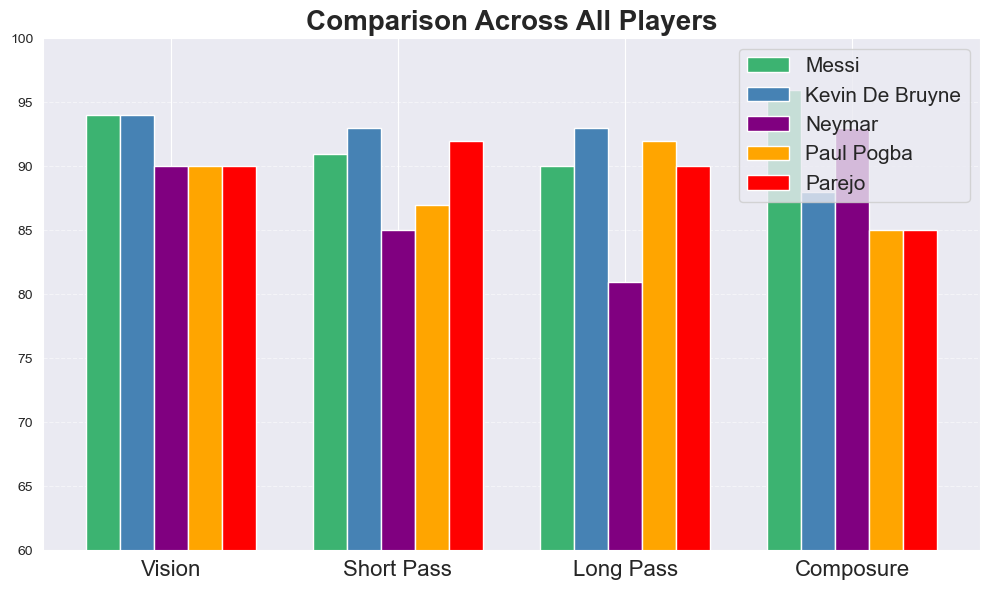

In [115]:
pass_masters = {
    'Messi': [94, 91, 90, 96],
    'Kevin De Bruyne': [94, 93, 93, 88],
    'Neymar': [90, 85, 81, 93],
    'Paul Pogba': [90, 87, 92, 85],
    'Parejo': [90, 92, 90, 85]
}

pass_attributes = ['Vision', 'Short Pass', 'Long Pass', 'Composure']

player_names = list(pass_masters.keys())
data = np.array(list(pass_masters.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 13))
axs = axs.flatten()

for i, (player, stats) in enumerate(pass_masters.items()):
    axs[i].bar(pass_attributes, stats, color=['mediumseagreen', 'steelblue', 'purple', 'orange'])
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_ylim(60, 100)
    axs[i].set_xticks(range(len(pass_attributes)))
    axs[i].set_xticklabels(pass_attributes, fontsize=16)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(pass_masters), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(pass_attributes))
width = 0.15
colors = ['mediumseagreen', 'steelblue', 'purple', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(player_names)):
    ax.bar(x + i*width, data[i], width, label=player_names[i], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(pass_attributes, fontsize=16)
ax.set_ylim(60, 100)
ax.set_title('Comparison Across All Players', fontsize=20, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Messi and Kevin De Bruyne remain the standout pass masters — both leading with elite vision (94) and excellent all-round passing. Messi’s composure at 96 is the highest in the group, reinforcing his ability to perform under pressure, while De Bruyne stands out as the most complete passer with consistently high stats across all attributes.

Neymar shows a slightly different profile, combining high composure (93) with the lowest long pass (81), suggesting a more short-range, creative playstyle rather than a deep-lying playmaker.

Paul Pogba and Parejo represent balanced midfield orchestrators — both strong in vision and passing, with Pogba excelling in long passing (92) and Parejo showing consistency across short and long distribution. Together, they highlight reliable playmakers who contribute without dominating a single attribute.

## Defensive

### Ball winners 

In [116]:
ball_winners = (
    df[
        (df['aggression'] >= 82) & 
        (df['stand_tackle'] >= 83) & 
        (df['strength'] >= 78)  
    ]
    [['player', 'club', 'aggression', 'stand_tackle', 'strength', 'interceptions']] 
    .sort_values(['stand_tackle', 'interceptions'], ascending=False)
    .head(5)
)
ball_winners

,player,club,aggression,stand_tackle,strength,interceptions
4211,Virgil van Dijk,Liverpool,85,91,93,89
39,Kalidou Koulibaly,Chelsea,83,89,93,85
1842,Joel Matip,Liverpool,82,86,81,84
5637,Chris Smalling,Roma,84,86,85,84
5673,Rodri,Manchester City,82,86,84,83


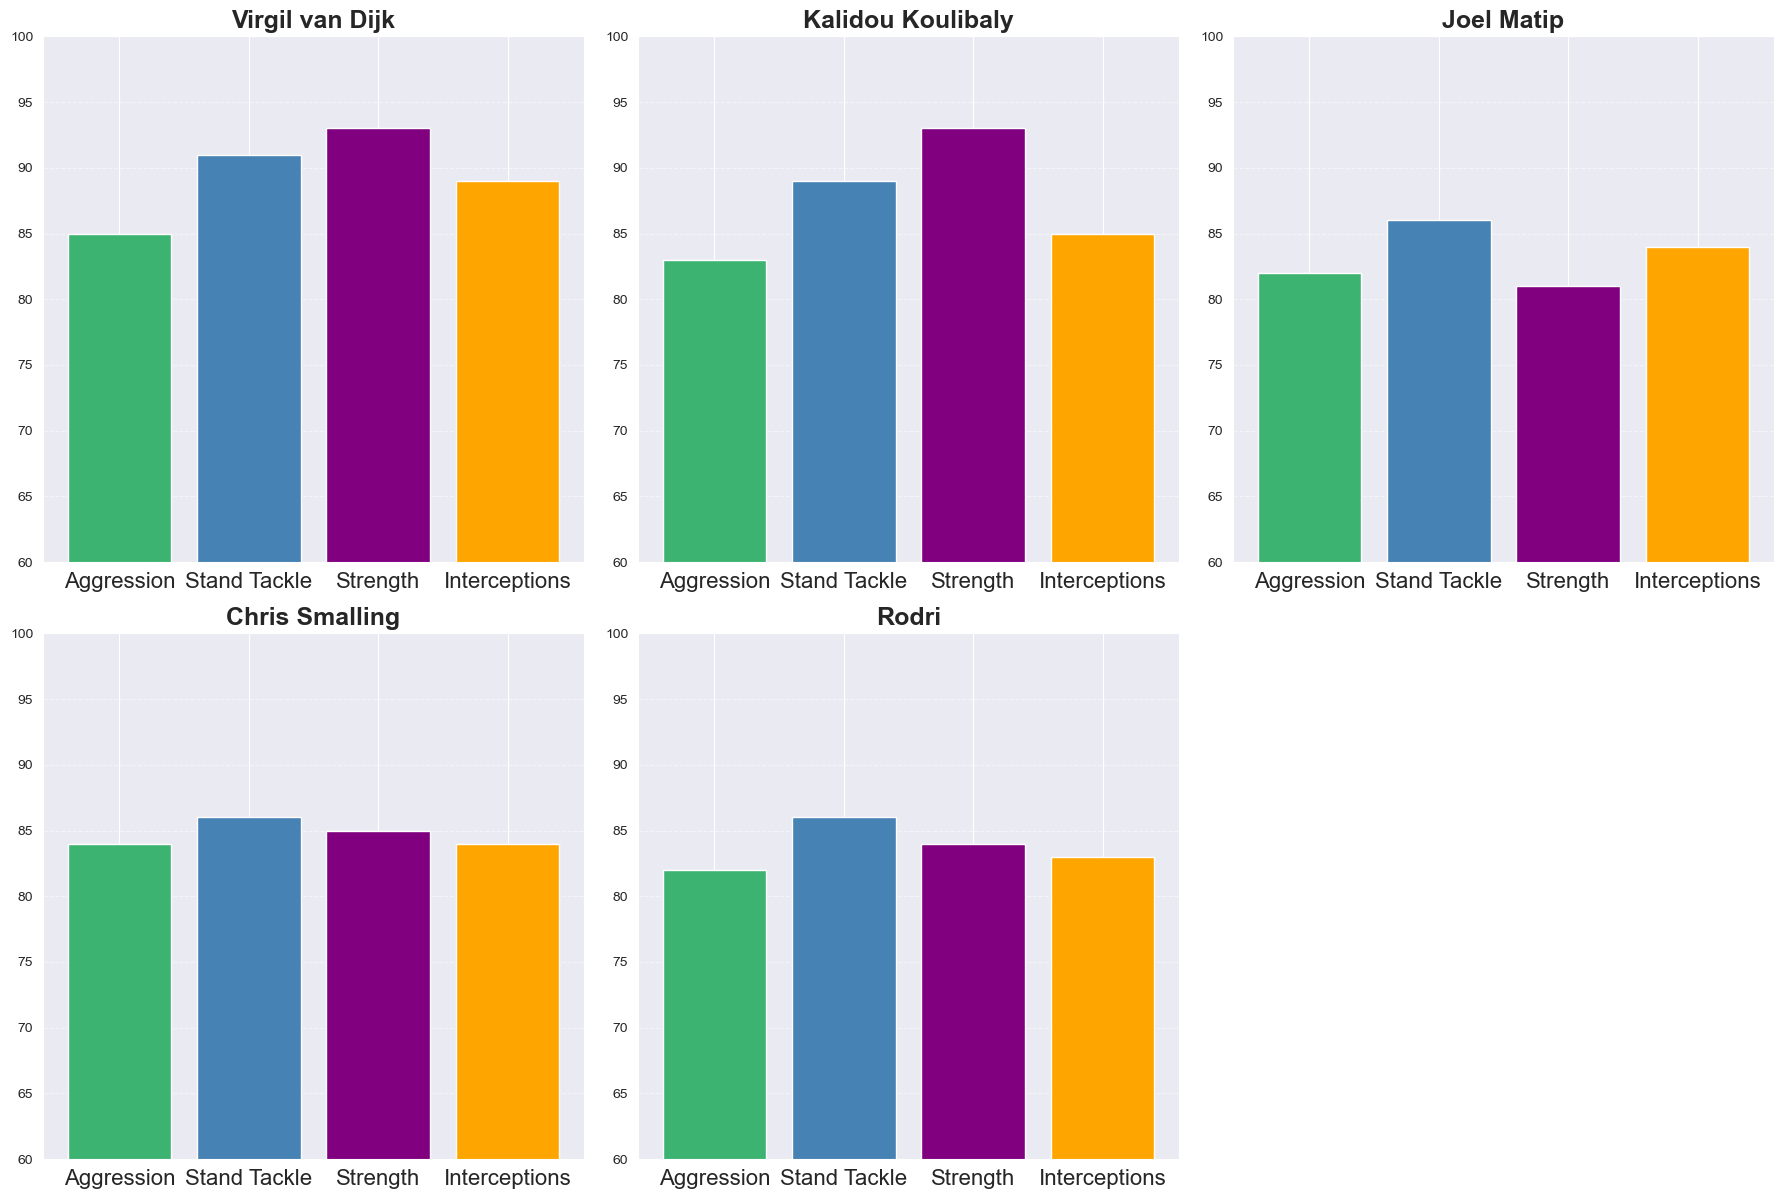

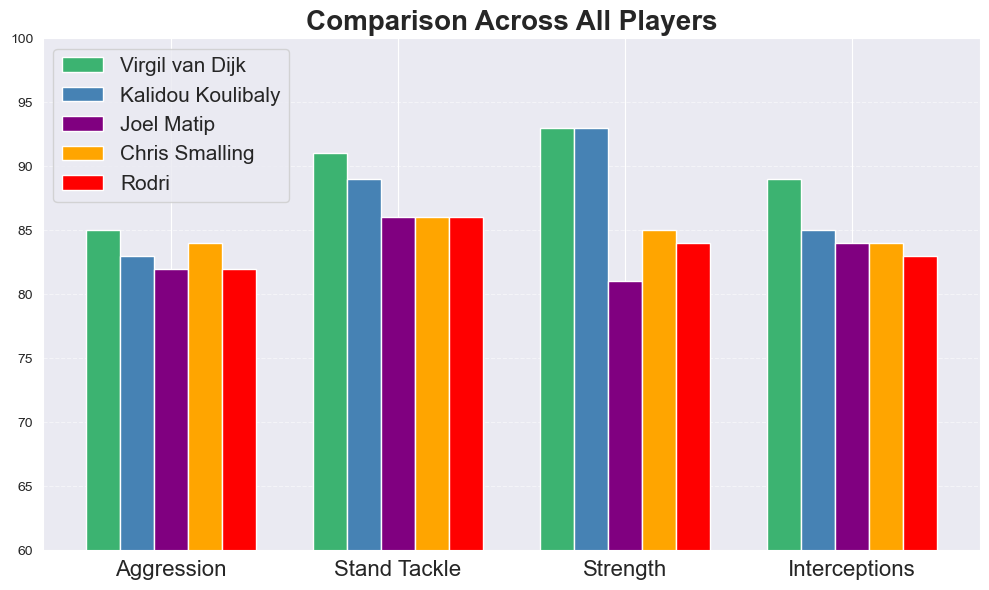

In [117]:
players = {
    'Virgil van Dijk': [85, 91, 93, 89],
    'Kalidou Koulibaly': [83, 89, 93, 85],
    'Joel Matip': [82, 86, 81, 84],
    'Chris Smalling': [84, 86, 85, 84],
    'Rodri': [82, 86, 84, 83]
}

attributes = ['Aggression', 'Stand Tackle', 'Strength', 'Interceptions']

player_names = list(players.keys())
data = np.array(list(players.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 13))
axs = axs.flatten()

for i, (player, stats) in enumerate(players.items()):
    axs[i].bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'purple', 'orange'])
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_ylim(60, 100)
    axs[i].set_xticks(range(len(attributes)))
    axs[i].set_xticklabels(attributes, fontsize=16)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(players), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['mediumseagreen', 'steelblue', 'purple', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(player_names)):
    ax.bar(x + i*width, data[i], width, label=player_names[i], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=16)
ax.set_ylim(60, 100)
ax.set_title('Comparison Across All Players', fontsize=20, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Virgil van Dijk and Kalidou Koulibaly stand out as the most dominant ball winners, combining elite tackling with exceptional strength and defensive awareness. Van Dijk leads in both stand tackle and interceptions, highlighting his ability to read the game, while Koulibaly matches him physically with top-tier strength.

Chris Smalling and Joel Matip represent balanced defenders — consistent across all attributes without extreme peaks, making them reliable and positionally disciplined.

Rodri offers a different profile as a defensive midfielder, relying more on positioning and game intelligence rather than pure physicality.

Overall, the chart highlights two key styles: physically dominant defenders and tactically intelligent ball winners.

### Silent_destroyers

In [118]:
silent_destroyers = (
    df[
        (df['interceptions'] >= 83) &  # lowered from 85
        (df['composure'] >= 83) &      # lowered from 85
        (df['reactions'] >= 83) &      # lowered from 85
        (df['stand_tackle'] >= 78)     # lowered from 80
    ]
    [['player', 'club', 'interceptions', 'composure', 'reactions', 'stand_tackle']]
    .sort_values(['interceptions', 'composure'], ascending=[False, False])
    .head(5)
)
silent_destroyers

,player,club,interceptions,composure,reactions,stand_tackle
4211,Virgil van Dijk,Liverpool,89,90,89,91
3120,Marco Verratti,Paris SG,86,94,87,82
5136,Joshua Kimmich,FC Bayern München,85,85,88,85
3138,Sergio Ramos,Paris SG,84,86,85,82
5637,Chris Smalling,Roma,84,85,83,86


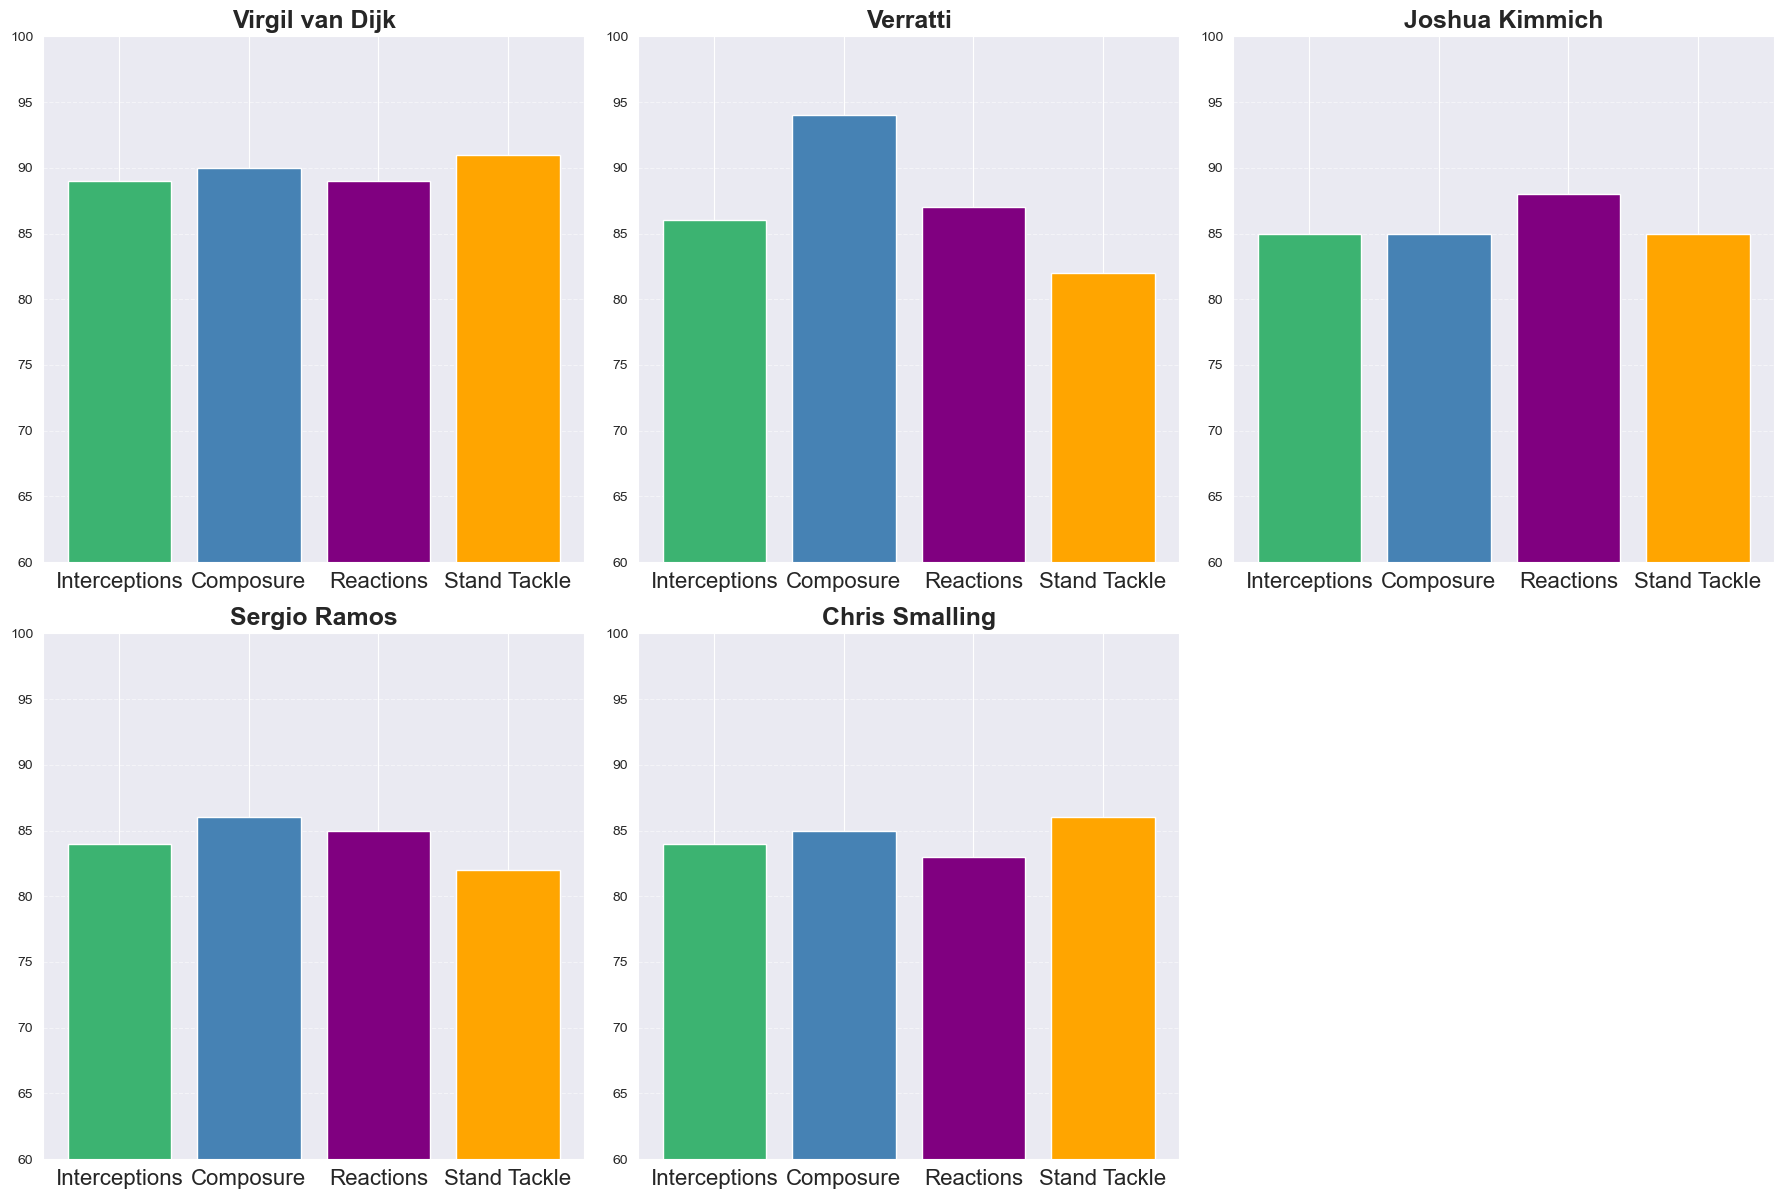

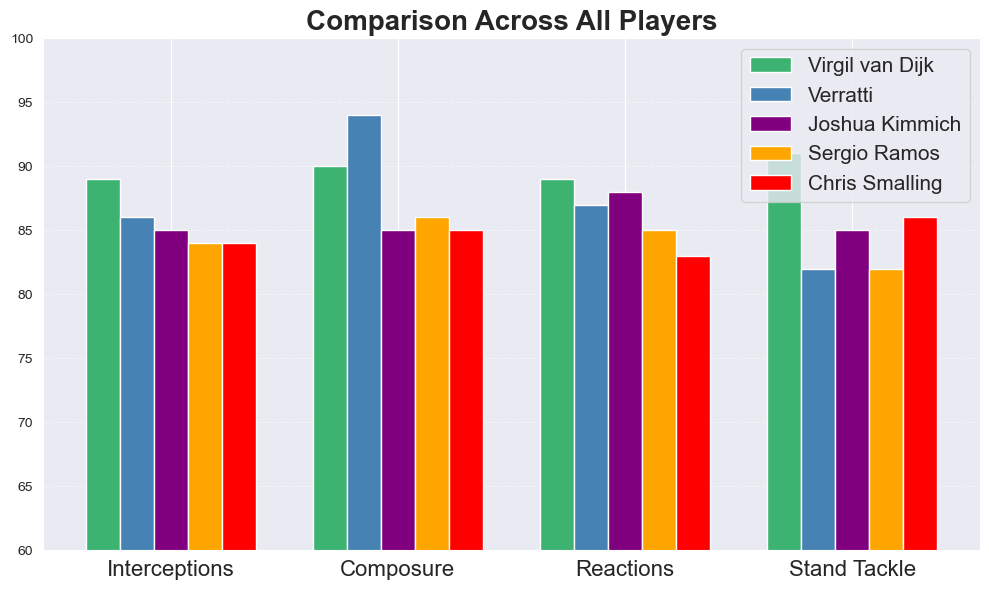

In [119]:
silent_destroyers = {
    'Virgil van Dijk': [89, 90, 89, 91],
    'Verratti': [86, 94, 87, 82],
    'Joshua Kimmich': [85, 85, 88, 85],
    'Sergio Ramos': [84, 86, 85, 82],
    'Chris Smalling': [84, 85, 83, 86]
}

attributes = ['Interceptions', 'Composure', 'Reactions', 'Stand Tackle']

player_names = list(silent_destroyers.keys())
data = np.array(list(silent_destroyers.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 13))
axs = axs.flatten()

for i, (player, stats) in enumerate(silent_destroyers.items()):
    axs[i].bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'purple', 'orange'])
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_ylim(60, 100)
    axs[i].set_xticks(range(len(attributes)))
    axs[i].set_xticklabels(attributes, fontsize=16)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(silent_destroyers), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['mediumseagreen', 'steelblue', 'purple', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(player_names)):
    ax.bar(x + i*width, data[i], width, label=player_names[i], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=16)
ax.set_ylim(60, 100)
ax.set_title('Comparison Across All Players', fontsize=20, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Virgil van Dijk leads the silent destroyers group with the highest interceptions (89) and stand tackle (91), reflecting his elite ability to regain possession while remaining physically dominant. Marco Verratti shows exceptional composure (94), emphasizing his intelligence and calmness in breaking up plays rather than purely physical defending.

Joshua Kimmich demonstrates a balanced defensive midfield profile — strong across interceptions, reactions, and stand tackle — making him a versatile disruptor. Sergio Ramos and Chris Smalling represent reliable defenders who maintain solid defensive metrics without dominating a single attribute.

Overall, this group highlights two styles of “silent destruction”: physically imposing defenders who win duels and tactically intelligent midfielders who break up plays through positioning and anticipation.

## Shooting

### Strikers 

In [120]:
strikers = (
    df[
        (df['finishing'] >= 90) &  
        (df['att_position'] >= 85) &      
        (df['composure'] >= 85)         
]
    [['player', 'club', 'composure', 'att_position','finishing']]
    .sort_values('att_position',ascending=False)    
).head(5)
strikers

,player,club,composure,att_position,finishing
3555,Lionel Messi,Paris SG,96,93,90
5678,Cristiano Ronaldo,Al Nassr,94,93,91
1965,Erling Haaland,Manchester City,86,92,94
5229,Kylian Mbappe,Paris SG,88,92,93
5675,Karim Benzema,Real Madrid,90,92,92


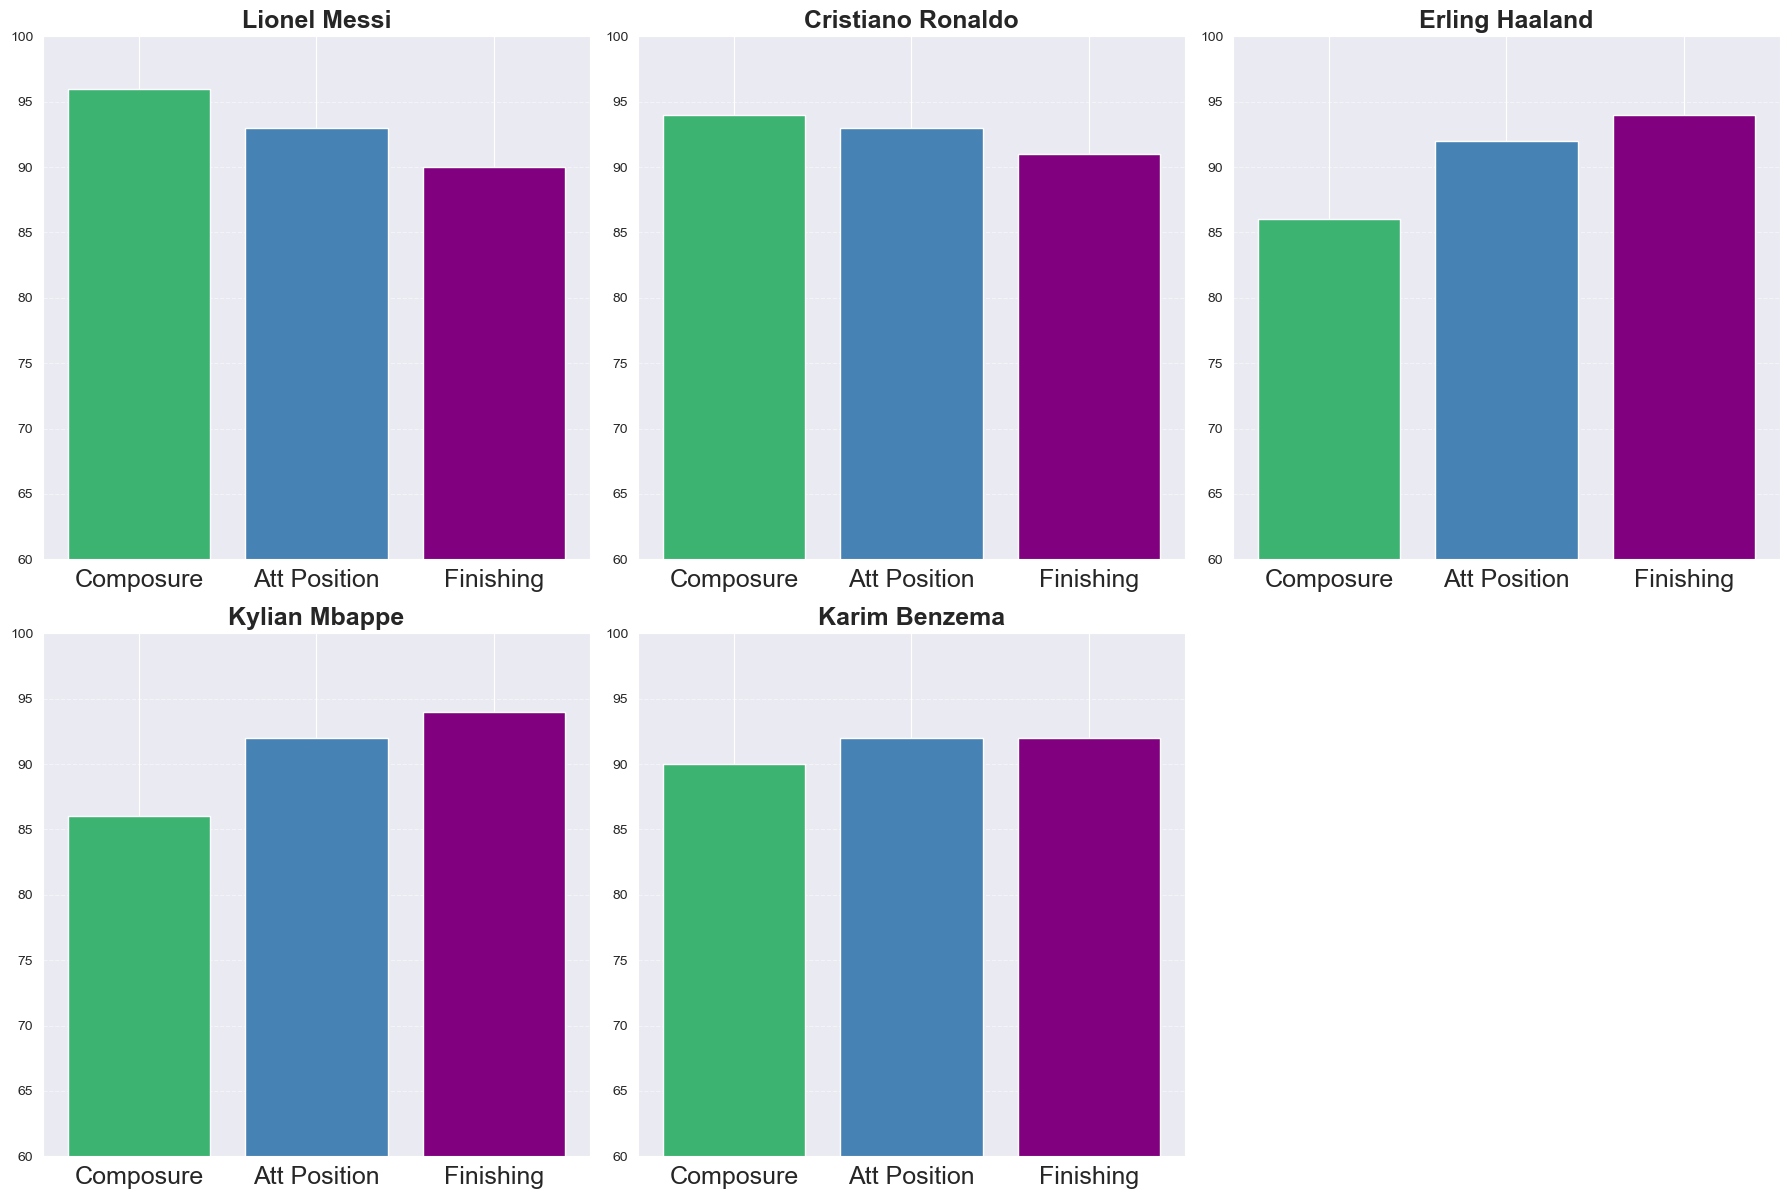

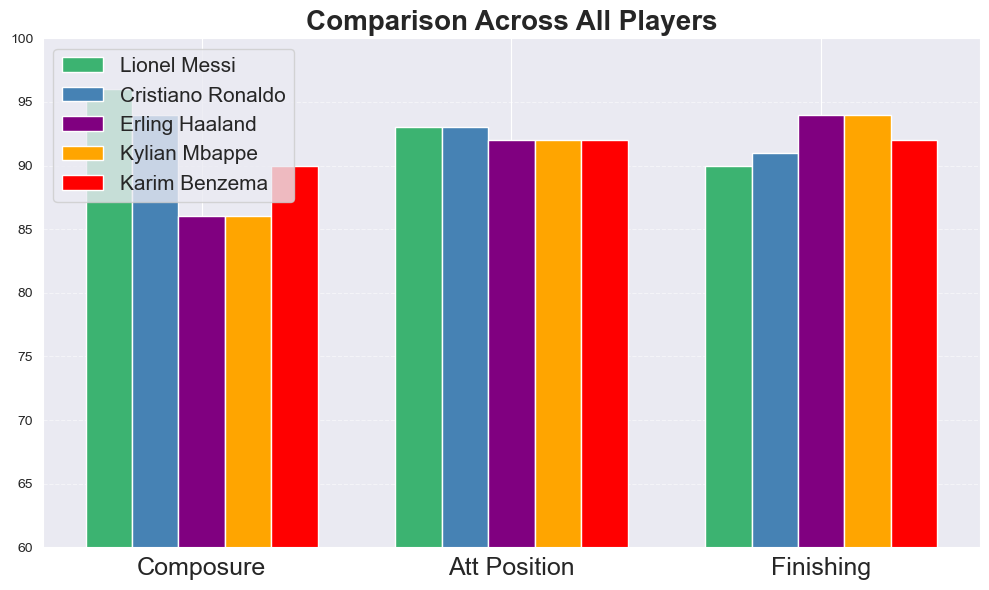

In [121]:
players = {
    'Lionel Messi': [96, 93, 90],
    'Cristiano Ronaldo': [94, 93, 91],
    'Erling Haaland': [86, 92, 94], 
    'Kylian Mbappe': [86, 92, 94],
    'Karim Benzema': [90, 92, 92]
}

attributes = ['Composure', 'Att Position', 'Finishing']

player_names = list(players.keys())
data = np.array(list(players.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 13))
axs = axs.flatten()

for i, (player, stats) in enumerate(players.items()):
    axs[i].bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'purple'])
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_ylim(60, 100)
    axs[i].set_xticks(range(len(attributes)))
    axs[i].set_xticklabels(attributes, fontsize=18)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(players), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['mediumseagreen', 'steelblue', 'purple', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(player_names)):
    ax.bar(x + i*width, data[i], width, label=player_names[i], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=18)
ax.set_ylim(60, 100)
ax.set_title('Comparison Across All Players', fontsize=20, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Lionel Messi stands out with the highest composure (96) and strong attacking positioning, reflecting his calmness and intelligence in front of goal. Cristiano Ronaldo shows a similarly balanced profile, excelling in finishing (91) while maintaining elite composure and positioning.

Erling Haaland and Kylian Mbappe are powerful, dynamic strikers — both show exceptional finishing (94) combined with high positioning, making them constant goal threats. Karim Benzema represents a well-rounded striker, strong across all three attributes without extreme peaks.

Overall, the group highlights two striker profiles: composed, intelligent playmakers (Messi, Ronaldo, Benzema) and explosive, goal-focused forwards (Haaland, Mbappe), showcasing different styles of elite goal-scoring ability.

### Long shooters

In [122]:
long = (
    df[
        (df['long_shots'] >= 84) & 
        (df['shot_power'] >= 84) &   
        (df['curve'] >= 80) &        
        (df['finishing'] >= 75)      
    ]
    [['player', 'club', 'long_shots', 'shot_power', 'curve', 'finishing', 'vision']]
    .sort_values(['long_shots', 'shot_power'], ascending=[False, False])
    .head(5)
)

long

,player,club,long_shots,shot_power,curve,finishing,vision
4849,Kevin De Bruyne,Manchester City,91,92,89,85,94
3555,Lionel Messi,Paris SG,91,86,93,90,94
3051,Bruno Fernandes,Manchester Utd,88,88,86,83,90
1991,Maximilian Arnold,VfL Wolfsburg,87,88,83,75,78
2330,Antoine Griezmann,Atlético de Madrid,85,84,87,84,87


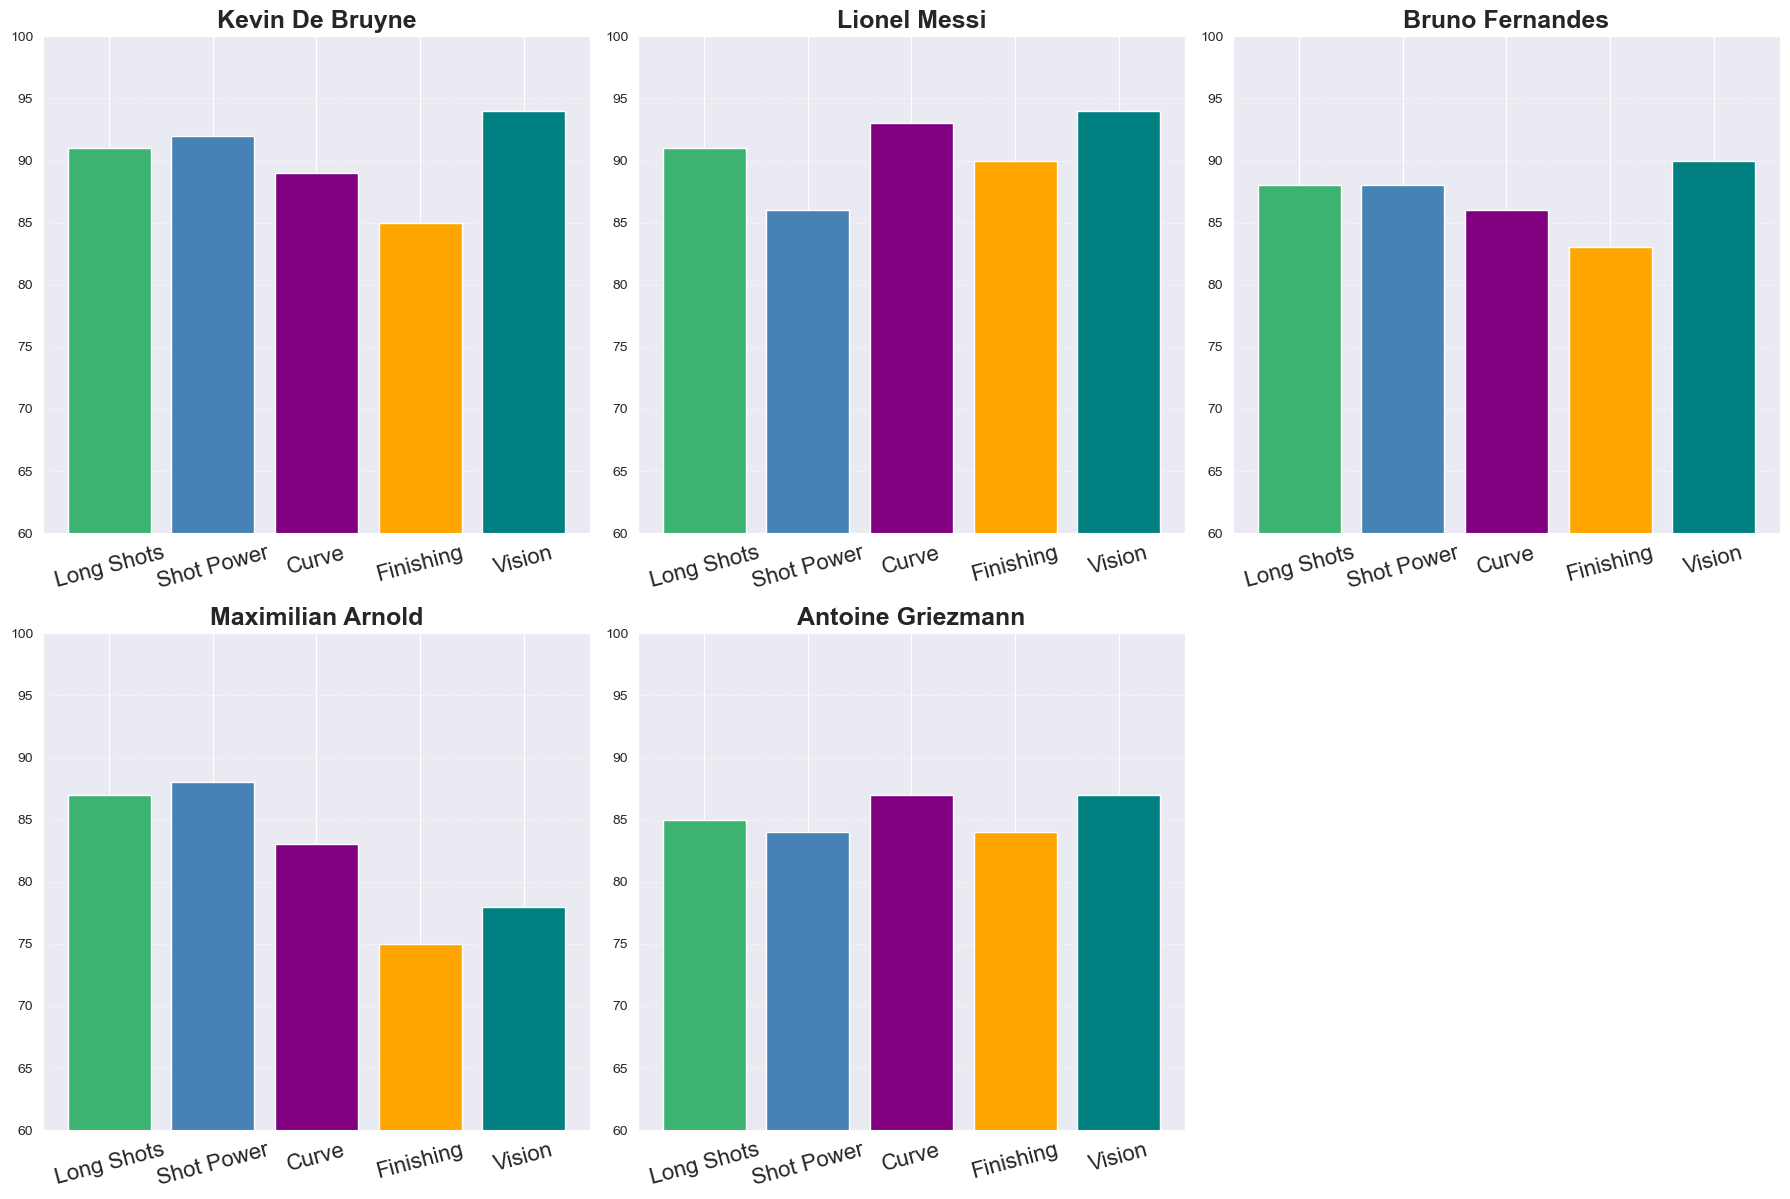

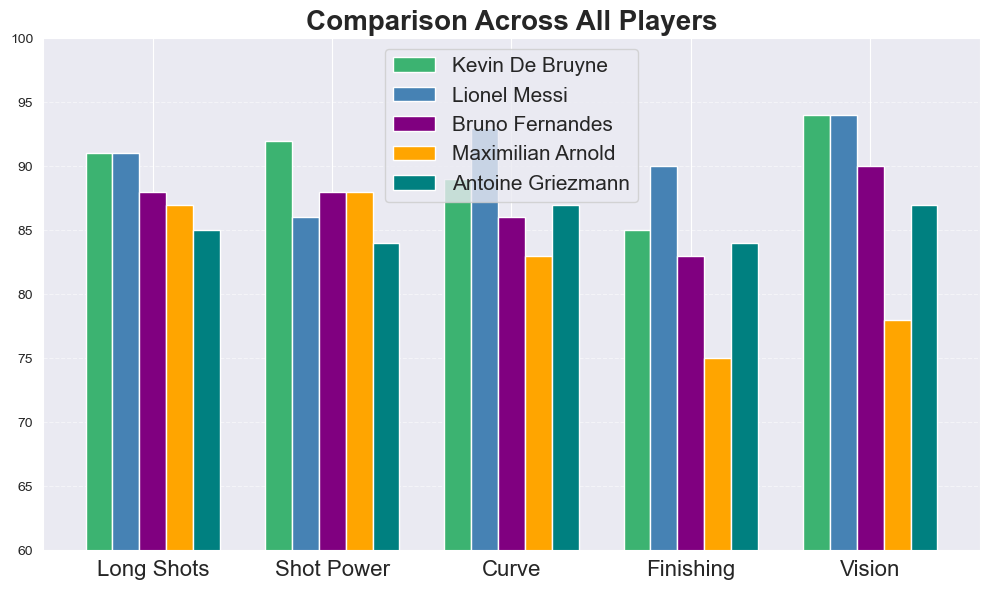

In [123]:
players = {
    'Kevin De Bruyne': [91, 92, 89, 85, 94],
    'Lionel Messi': [91, 86, 93, 90, 94],
    'Bruno Fernandes': [88, 88, 86, 83, 90],
    'Maximilian Arnold': [87, 88, 83, 75, 78],
    'Antoine Griezmann': [85, 84, 87, 84, 87]
}

attributes = ['Long Shots', 'Shot Power', 'Curve', 'Finishing', 'Vision']

player_names = list(players.keys())
data = np.array(list(players.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 13))
axs = axs.flatten()

for i, (player, stats) in enumerate(players.items()):
    axs[i].bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'purple', 'orange', 'teal'])
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_ylim(60, 100)
    axs[i].set_xticks(range(len(attributes)))
    axs[i].set_xticklabels(attributes, fontsize=16, rotation=15)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(players), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['mediumseagreen', 'steelblue', 'purple', 'orange', 'teal']

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(player_names)):
    ax.bar(x + i*width, data[i], width, label=player_names[i], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=16)
ax.set_ylim(60, 100)
ax.set_title('Comparison Across All Players', fontsize=20, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Kevin De Bruyne and Lionel Messi lead the long-shot specialists — both showing elite long shots (91) with high shot power and vision, reflecting their ability to score from distance and create opportunities. Messi also excels in curve (93) and finishing (90), demonstrating his technical finesse in set-pieces and long-range attempts.

Bruno Fernandes combines strong long shots and shot power with solid vision (90), making him a reliable goal threat from outside the box. Maximilian Arnold shows balanced attributes, slightly lower in finishing, indicating more of a supporting playmaker role. Antoine Griezmann offers consistency across all five metrics, with curve and vision slightly stronger than shot power, reflecting his ability to deliver precise long-range shots.

Overall, the group highlights two styles: technically gifted creators (Messi, De Bruyne) and versatile attacking midfielders who contribute consistently from distance (Fernandes, Arnold, Griezmann).

## Goalkeeping

### Elite GK's

In [124]:
# Filter only goalkeepers first 
gk_df = df[df['gk_diving'].notna()]  

elite_gk = (
    gk_df[
        (gk_df['gk_reflexes'] >= 80) &  
        (gk_df['gk_handling'] >= 80) &
        (gk_df['gk_positioning'] >= 75)
    ]
    [['player', 'club', 'gk_reflexes', 'gk_handling', 'gk_positioning']]
    .sort_values('gk_reflexes', ascending=False)
)
elite_gk

,player,club,gk_reflexes,gk_handling,gk_positioning
2458,Gianluigi Donnarumma,Paris SG,89,83,85
3119,Keylor Navas,Nott'm Forest,87,84,87
2763,Koen Casteels,VfL Wolfsburg,86,82,84
3451,Yassine Bounou,Sevilla FC,85,83,84
2384,Lucas Mantela,Brazil,81,87,77


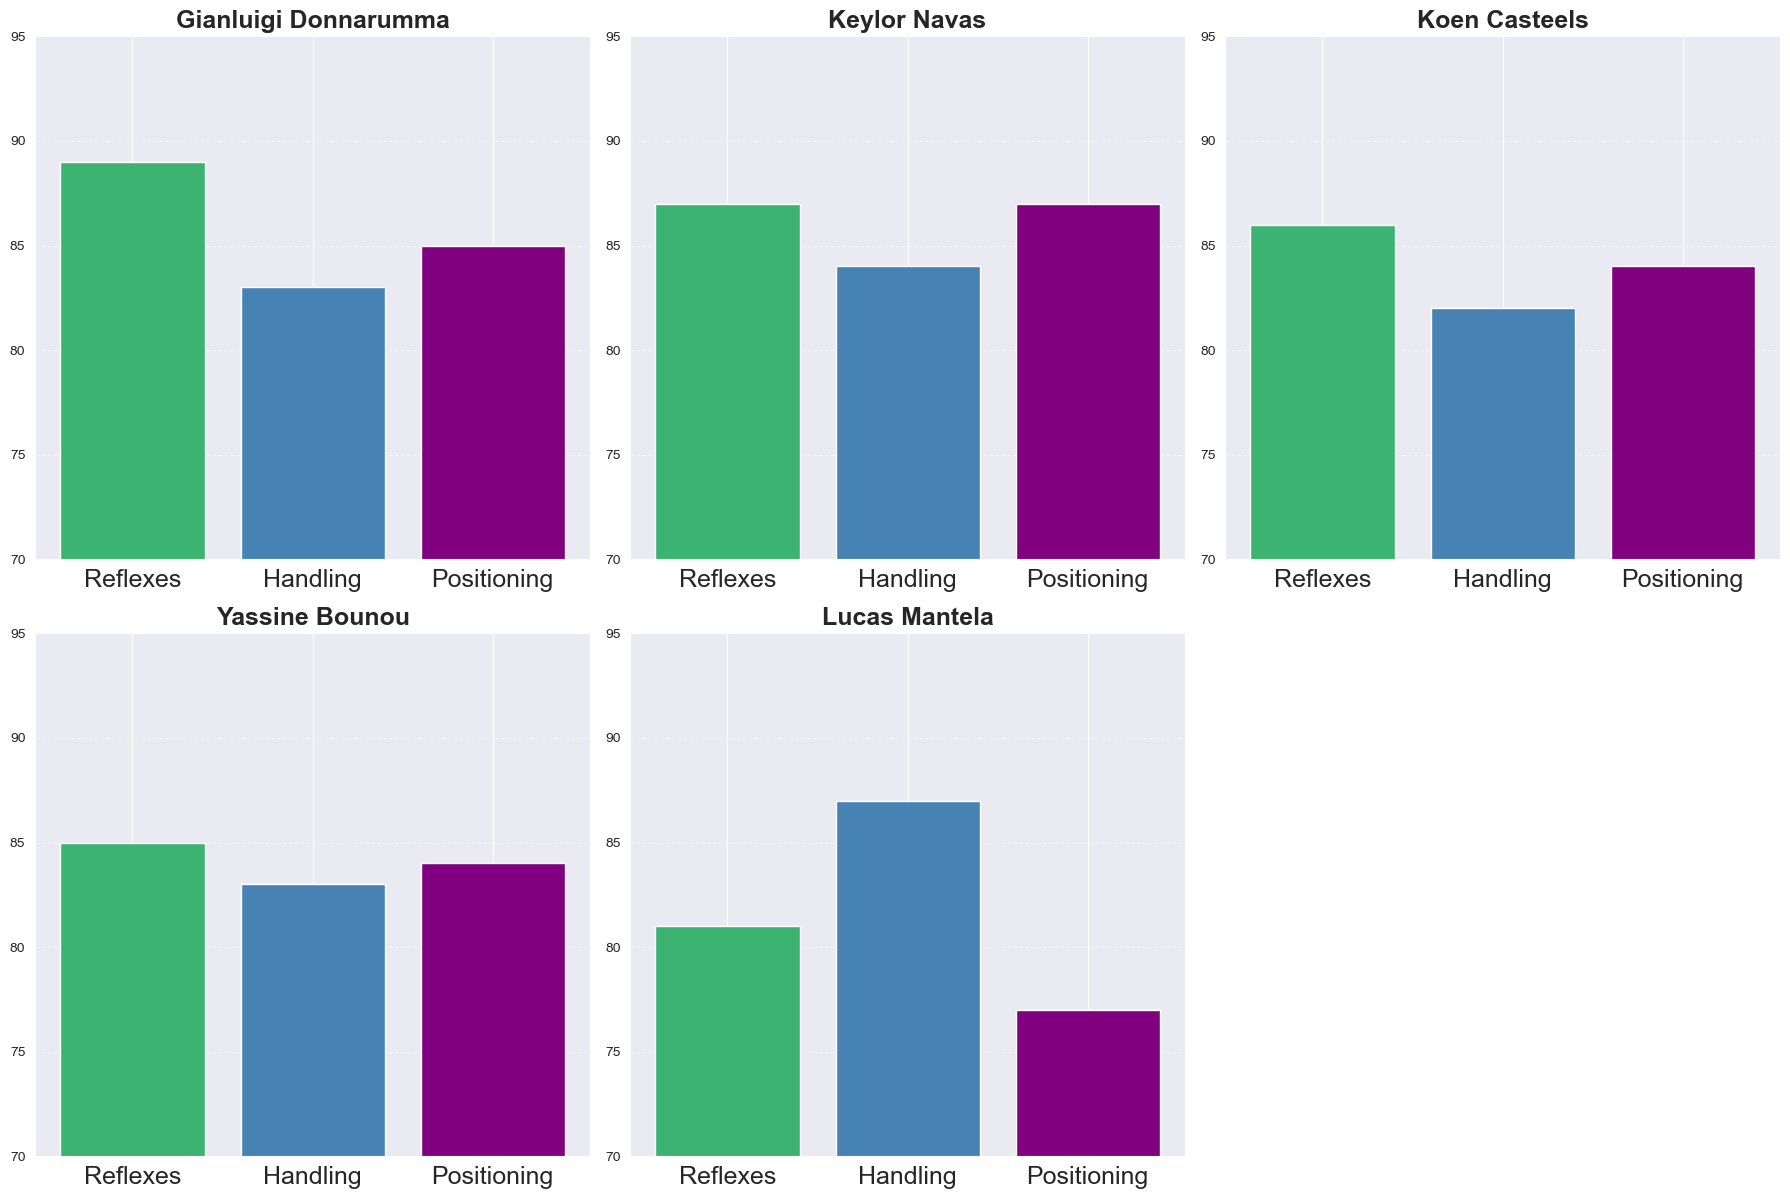

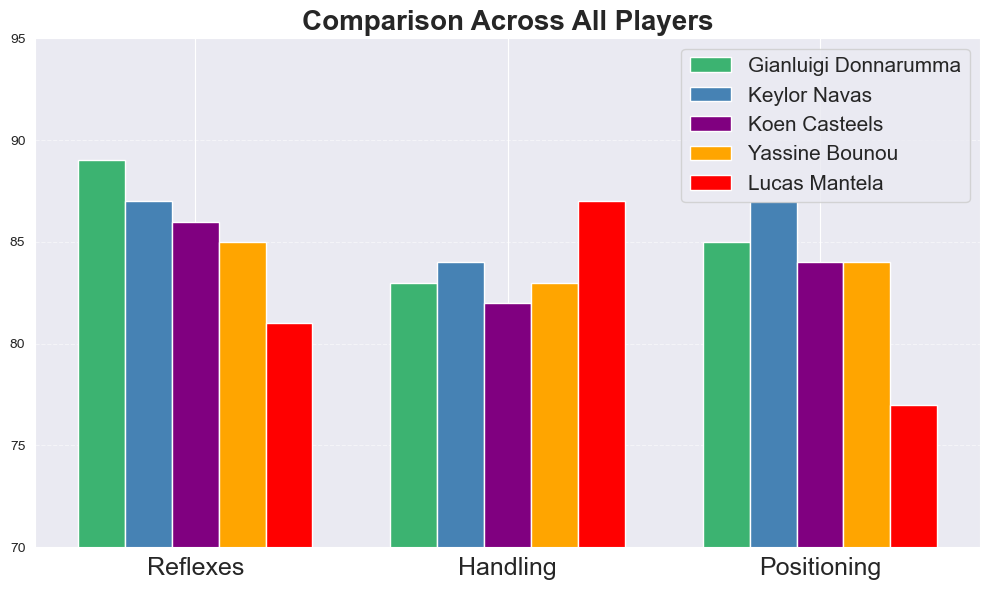

In [125]:
goalkeepers = {
    'Gianluigi Donnarumma': [89, 83, 85],
    'Keylor Navas': [87, 84, 87],
    'Koen Casteels': [86, 82, 84],
    'Yassine Bounou': [85, 83, 84],
    'Lucas Mantela': [81, 87, 77]
}

attributes = ['Reflexes', 'Handling', 'Positioning']

player_names = list(goalkeepers.keys())
data = np.array(list(goalkeepers.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 13))
axs = axs.flatten()

for i, (player, stats) in enumerate(goalkeepers.items()):
    axs[i].bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'purple'])
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_ylim(70, 95)
    axs[i].set_xticks(range(len(attributes)))
    axs[i].set_xticklabels(attributes, fontsize=18)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(goalkeepers), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['mediumseagreen', 'steelblue', 'purple', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(player_names)):
    ax.bar(x + i*width, data[i], width, label=player_names[i], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=18)
ax.set_ylim(70, 95)
ax.set_title('Comparison Across All Players', fontsize=20, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Gianluigi Donnarumma stands out with elite reflexes (89) and strong positioning (85), reflecting his ability to react quickly and command the penalty area. Keylor Navas shows a balanced profile, excelling in positioning (87) and reflexes (87), making him highly reliable in critical situations.

Koen Casteels and Yassine Bounou demonstrate consistent goalkeeping metrics, combining solid reflexes and handling with good positioning, suitable for maintaining stability in defense. Lucas Mantela represents a more specialized profile, with exceptional handling (87) but slightly lower reflexes (81) and positioning (77), indicating a strengths-based approach rather than all-around dominance.

Overall, this group highlights two goalkeeper styles: reactive shot-stoppers with high reflexes (Donnarumma, Navas) and steady, handling-focused keepers who maintain consistency across defensive phases (Casteels, Bounou, Mantela).

### Penalty Stoppers

In [126]:
penalty_specialists = (
    gk_df[
        (gk_df['gk_reflexes'] >= 85) &  
        (gk_df['gk_positioning'] >= 78) &  
        (gk_df['height'] >= 185)  
    ]
    [['player', 'club', 'gk_reflexes', 'gk_positioning', 'height', 'gk_diving']]
    .sort_values(['gk_reflexes', 'height'], ascending=[False, False])
    .head(5)
)
penalty_specialists

,player,club,gk_reflexes,gk_positioning,height,gk_diving
2458,Gianluigi Donnarumma,Paris SG,89,85,196,90
2634,Dominik Livakovic,Dinamo Zagreb,87,79,187,80
3119,Keylor Navas,Nott'm Forest,87,87,185,87
2763,Koen Casteels,VfL Wolfsburg,86,84,197,84
3451,Yassine Bounou,Sevilla FC,85,84,195,83


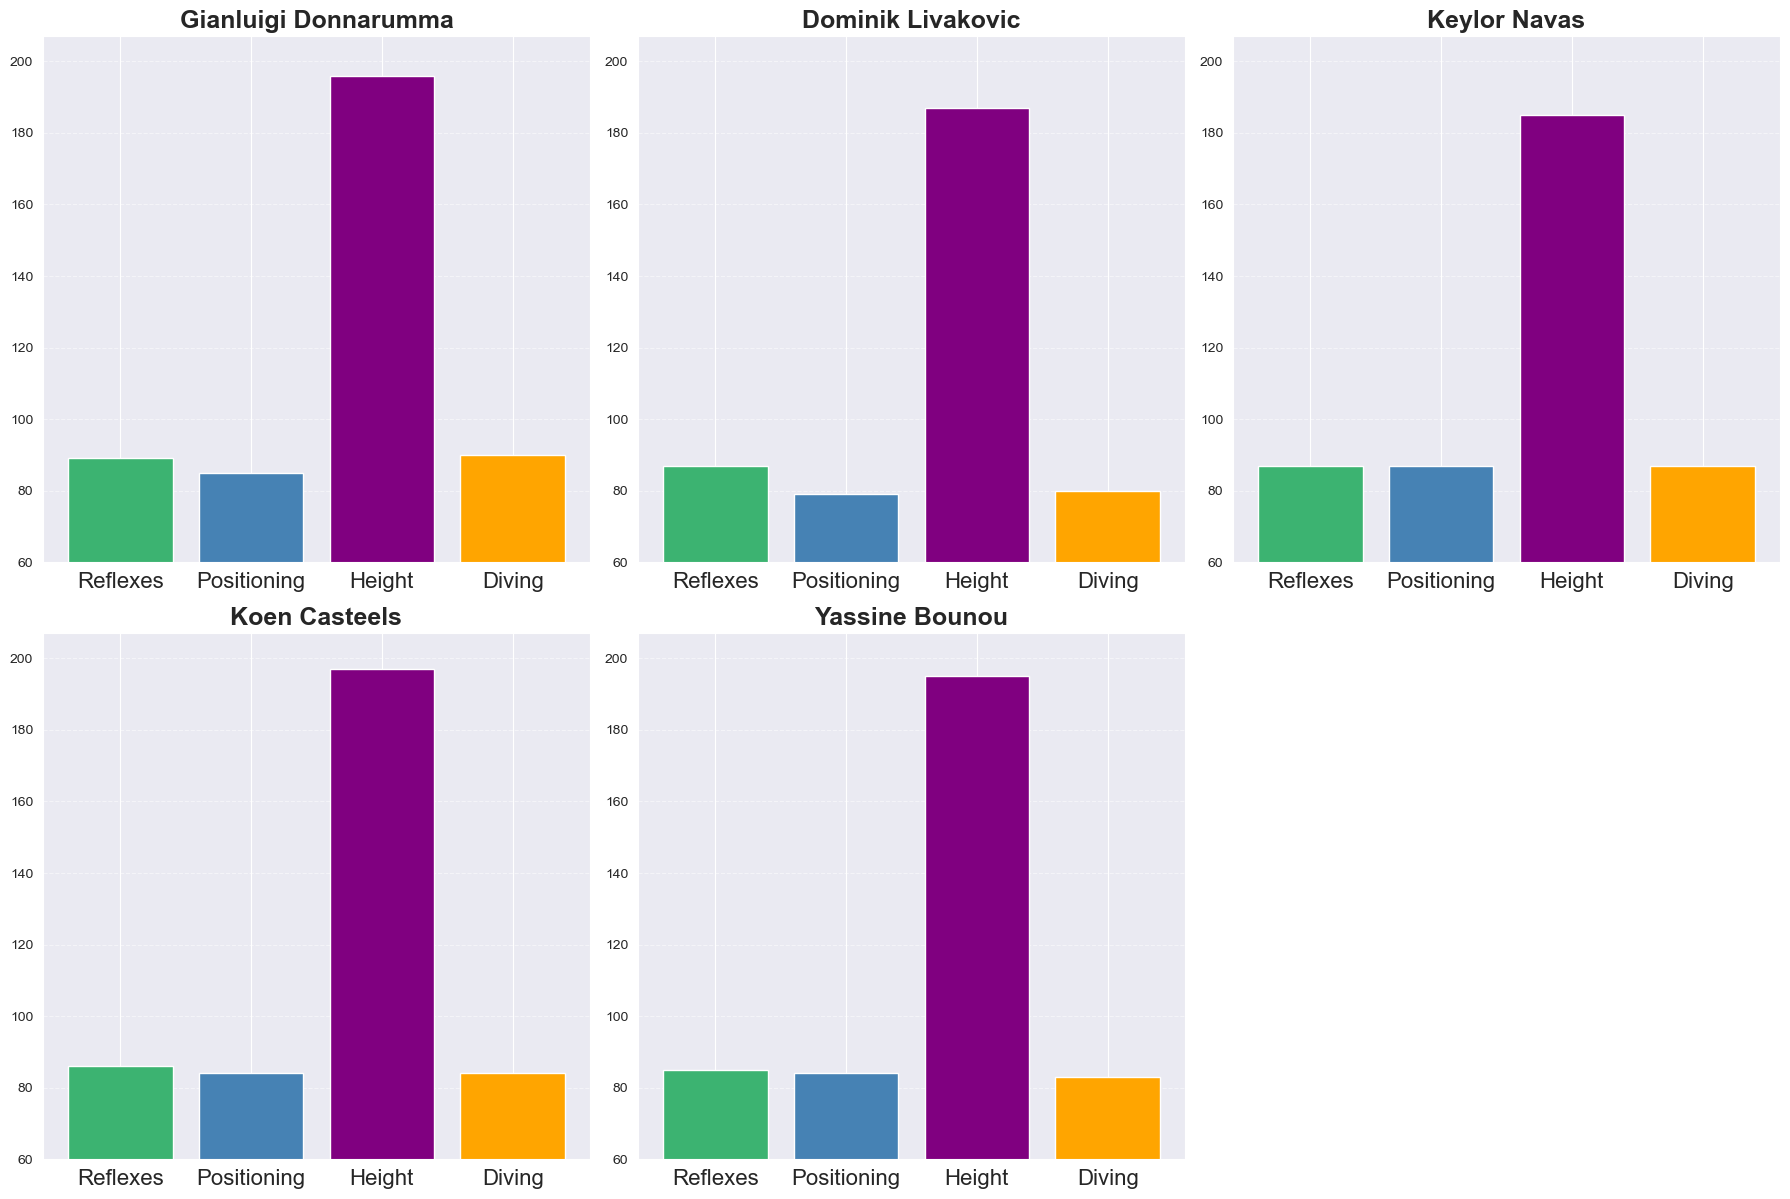

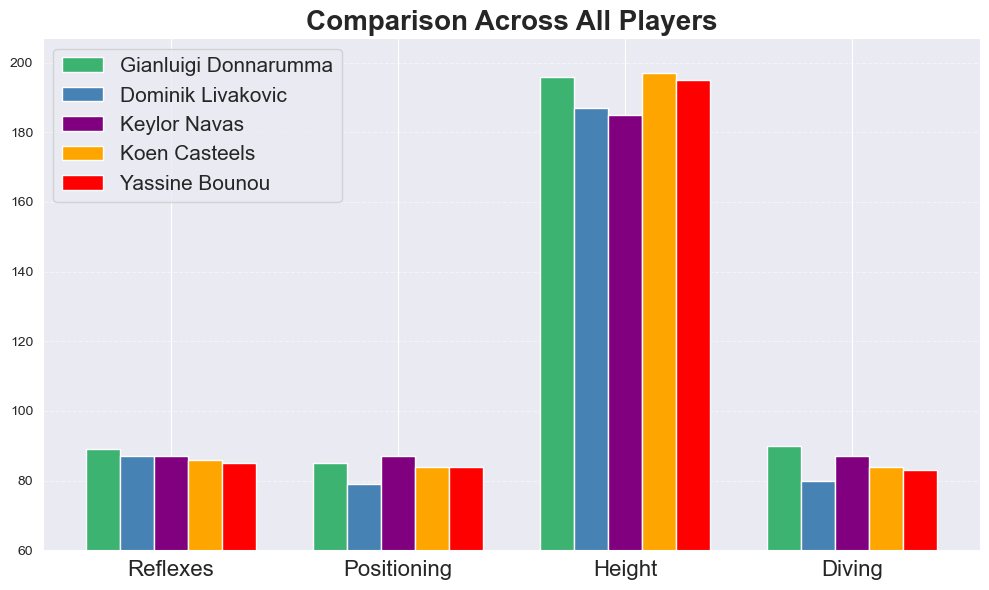

In [127]:
goalkeepers = {
    'Gianluigi Donnarumma': [89, 85, 196, 90],
    'Dominik Livakovic': [87, 79, 187, 80],
    'Keylor Navas': [87, 87, 185, 87],
    'Koen Casteels': [86, 84, 197, 84],
    'Yassine Bounou': [85, 84, 195, 83]
}

attributes = ['Reflexes', 'Positioning', 'Height', 'Diving']

player_names = list(goalkeepers.keys())
data = np.array(list(goalkeepers.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 13))
axs = axs.flatten()

for i, (player, stats) in enumerate(goalkeepers.items()):
    axs[i].bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'purple', 'orange'])
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_ylim(60, max([max(s) for s in goalkeepers.values()]) + 10)
    axs[i].set_xticks(range(len(attributes)))
    axs[i].set_xticklabels(attributes, fontsize=16)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(goalkeepers), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['mediumseagreen', 'steelblue', 'purple', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(player_names)):
    ax.bar(x + i*width, data[i], width, label=player_names[i], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=16)
ax.set_ylim(60, max([max(s) for s in goalkeepers.values()]) + 10)
ax.set_title('Comparison Across All Players', fontsize=20, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Gianluigi Donnarumma stands out with elite reflexes (89) and diving (90), complemented by his towering height (196 cm), making him a complete, commanding goalkeeper. Keylor Navas shows a balanced profile with exceptional positioning (87) and strong reflexes (87), reflecting his reliability in goal.

Koen Casteels and Yassine Bounou demonstrate solid goalkeeping metrics with impressive height and consistent diving ability, making them strong aerial and shot-stopping presences. Dominik Livakovic excels in reflexes (87) but has slightly lower positioning (79) and diving (80), showing a reactive style rather than all-around dominance.

Overall, the group illustrates two key goalkeeper profiles: tall, commanding shot-stoppers with strong reflexes (Donnarumma, Casteels, Bounou) and agile, positionally intelligent keepers (Navas, Livakovic) capable of critical saves.

## Physical Traits

### Center Backs (CB)

In [128]:
CB = (
    df[
        (df['height'] >= 185) &  
        (df['jumping'] >= 80) &      
        (df['heading'] >= 85) &
        (df['strength'] >= 85)
]
    [['player', 'club', 'height', 'jumping','strength','heading']]
    .sort_values('strength',ascending=False)    
).head(5)
CB

,player,club,height,jumping,strength,heading
4211,Virgil van Dijk,Liverpool,193,88,93,86
943,Milan Pavkov,Al Fayha,193,92,89,86
3515,Maximiliano Gomez,Trabzonspor,186,83,88,87
1856,Raphael Varane,Manchester Utd,191,80,87,85
2074,Luuk de Jong,PSV,189,90,87,93


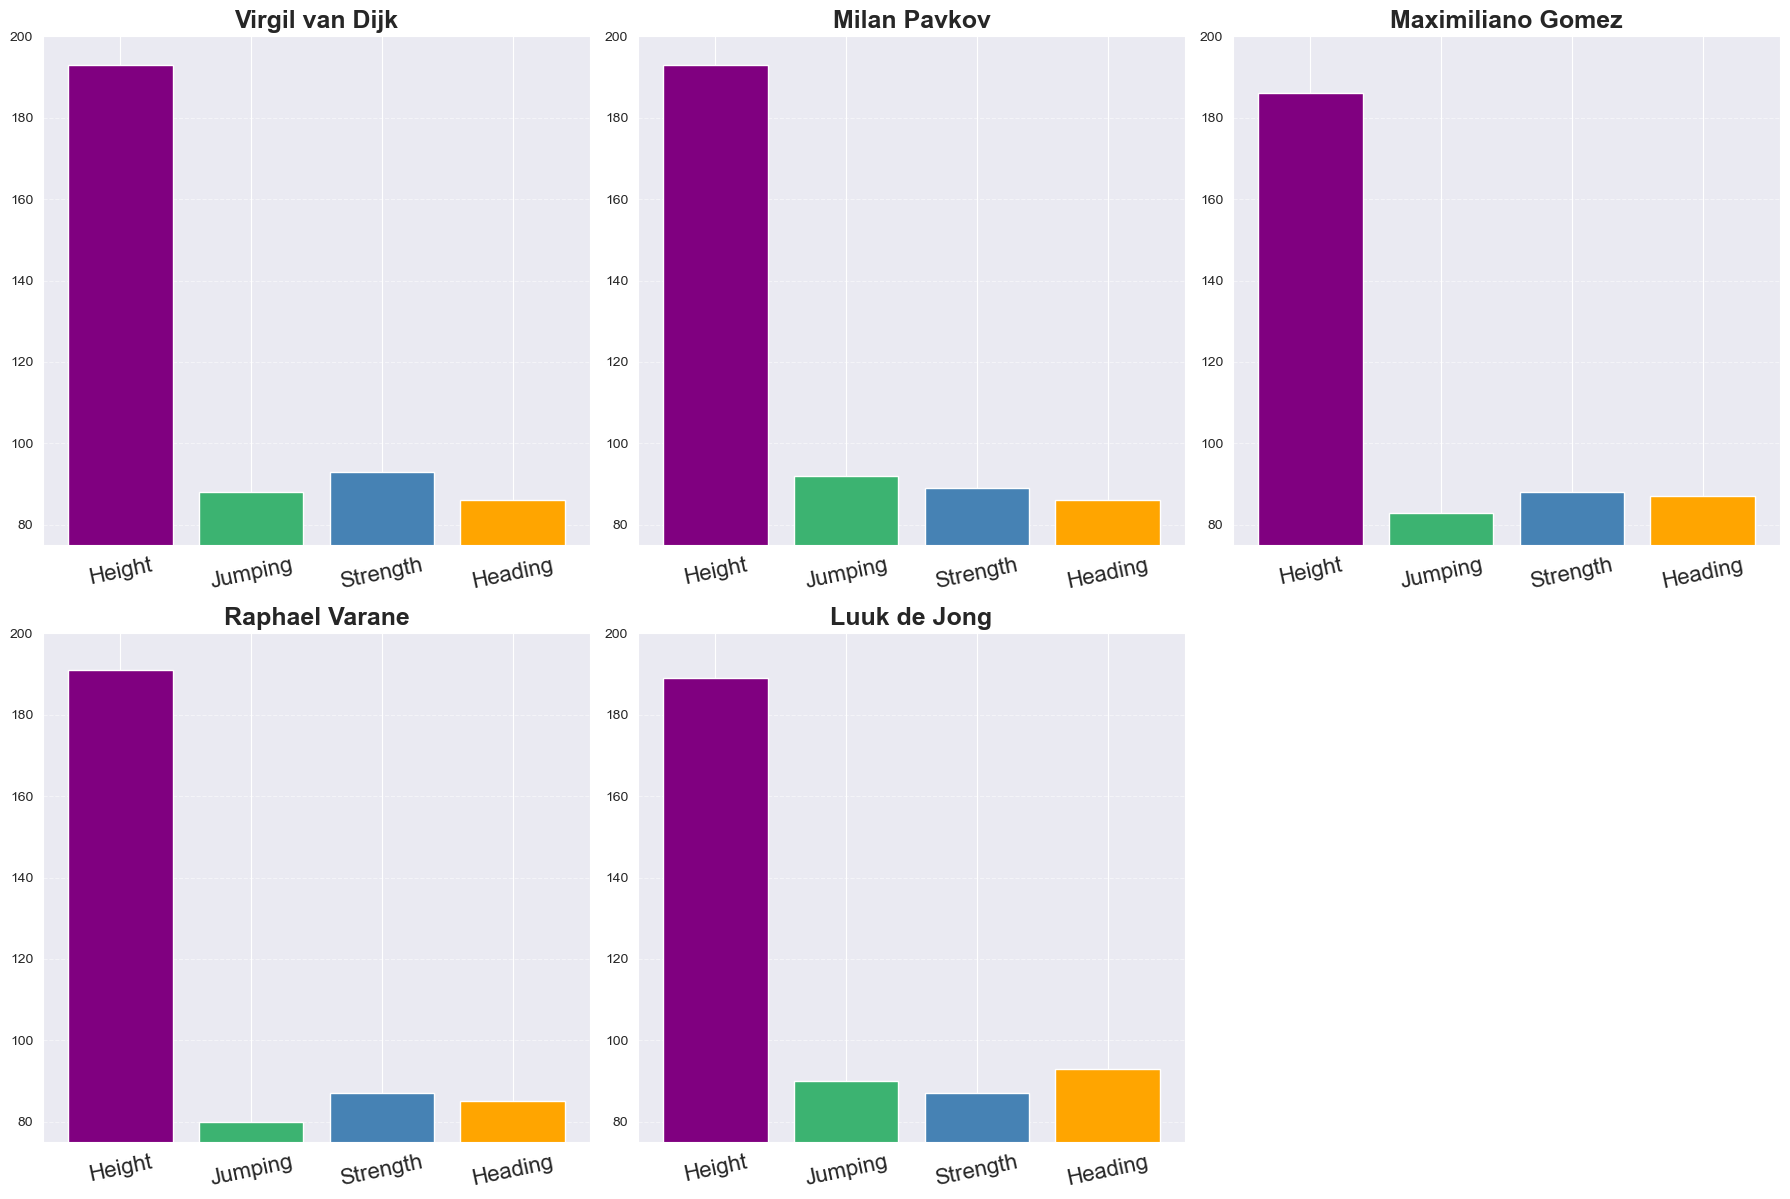

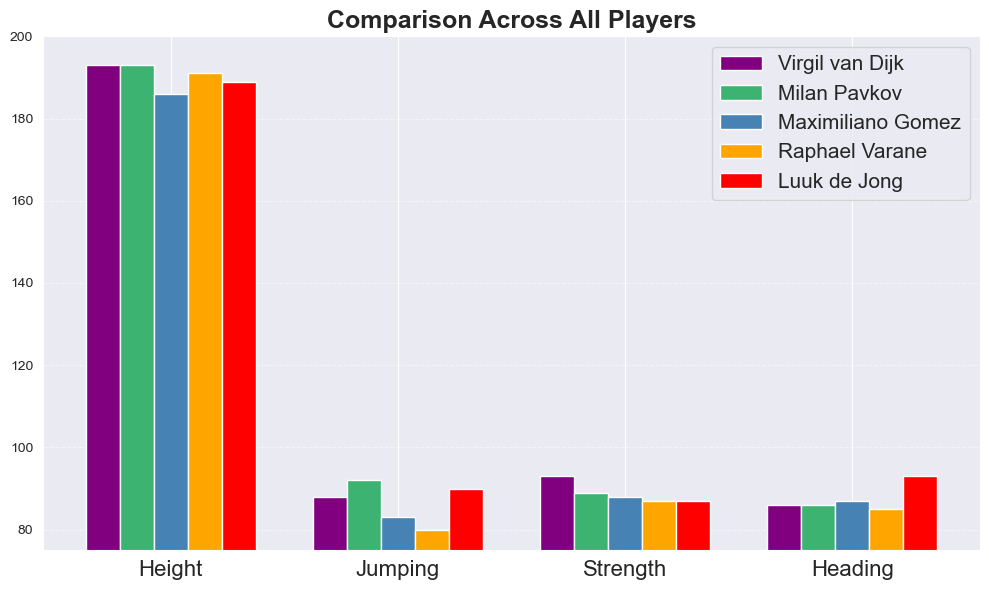

In [129]:
players = {
    'Virgil van Dijk': [193, 88, 93, 86],
    'Milan Pavkov': [193, 92, 89, 86],
    'Maximiliano Gomez': [186, 83, 88, 87],
    'Raphael Varane': [191, 80, 87, 85],
    'Luuk de Jong': [189, 90, 87, 93]
}

attributes = ['Height', 'Jumping', 'Strength', 'Heading']

player_names = list(players.keys())
data = np.array(list(players.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 13))
axs = axs.flatten()

for i, (player, stats) in enumerate(players.items()):
    axs[i].bar(attributes, stats, color=['purple', 'mediumseagreen', 'steelblue', 'orange'])
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_ylim(75, 200)
    axs[i].set_xticks(range(len(attributes)))
    axs[i].set_xticklabels(attributes, fontsize=16, rotation=12)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(players), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['purple', 'mediumseagreen', 'steelblue', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(player_names)):
    ax.bar(x + i*width, data[i], width, label=player_names[i], color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=16)
ax.set_ylim(75, 200)
ax.set_title('Comparison Across All Players', fontsize=18, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Virgil van Dijk demonstrates a balanced aerial and physical presence with excellent height (193 cm) and elite strength (93), complemented by strong jumping (88) and heading (86), making him a dominant defensive force. Milan Pavkov stands out with exceptional jumping ability (92) and solid strength (89), combined with towering height (193 cm), making him a significant aerial threat.

Luuk de Jong excels in heading (93) and jumping (90), making him the most dangerous target in offensive aerial duels, while maintaining solid strength (87) and height (189 cm). Maximiliano Gomez shows a more balanced profile with consistent heading (87), strength (88), and jumping (83), suitable for both attack and defense. Raphael Varane provides reliable defensive metrics with good height (191 cm), strength (87), and jumping (80), supporting a stable backline.

Overall, the dataset illustrates two key player profiles: dominant aerial attackers (Luuk de Jong, Milan Pavkov) and physically strong, defensively reliable center-backs (Virgil van Dijk, Raphael Varane, Maximiliano Gomez) capable of winning duels and controlling the air.

### Wingers

In [130]:
wingers = (
    df[
        (df['sprint_speed'] >= 85) &  
        (df['acceleration'] >= 85) &  
        (df['agility'] >= 80) &       
        (df['dribbling'] >= 80)       
    ]
    [['player', 'club', 'sprint_speed', 'acceleration', 'dribbling', 'crossing']]  
    .sort_values(['sprint_speed', 'dribbling'], ascending=[False, False])
    .head(5)  
)
wingers

,player,club,sprint_speed,acceleration,dribbling,crossing
5229,Kylian Mbappe,Paris SG,97,97,93,78
4496,Galeno,FC Porto,93,91,83,68
5175,Hirving Lozano,Napoli FC,93,92,83,73
143,Kamaldeen Sulemana,Southampton,93,92,80,64
5188,Rafael Leao,Milan,92,90,89,75


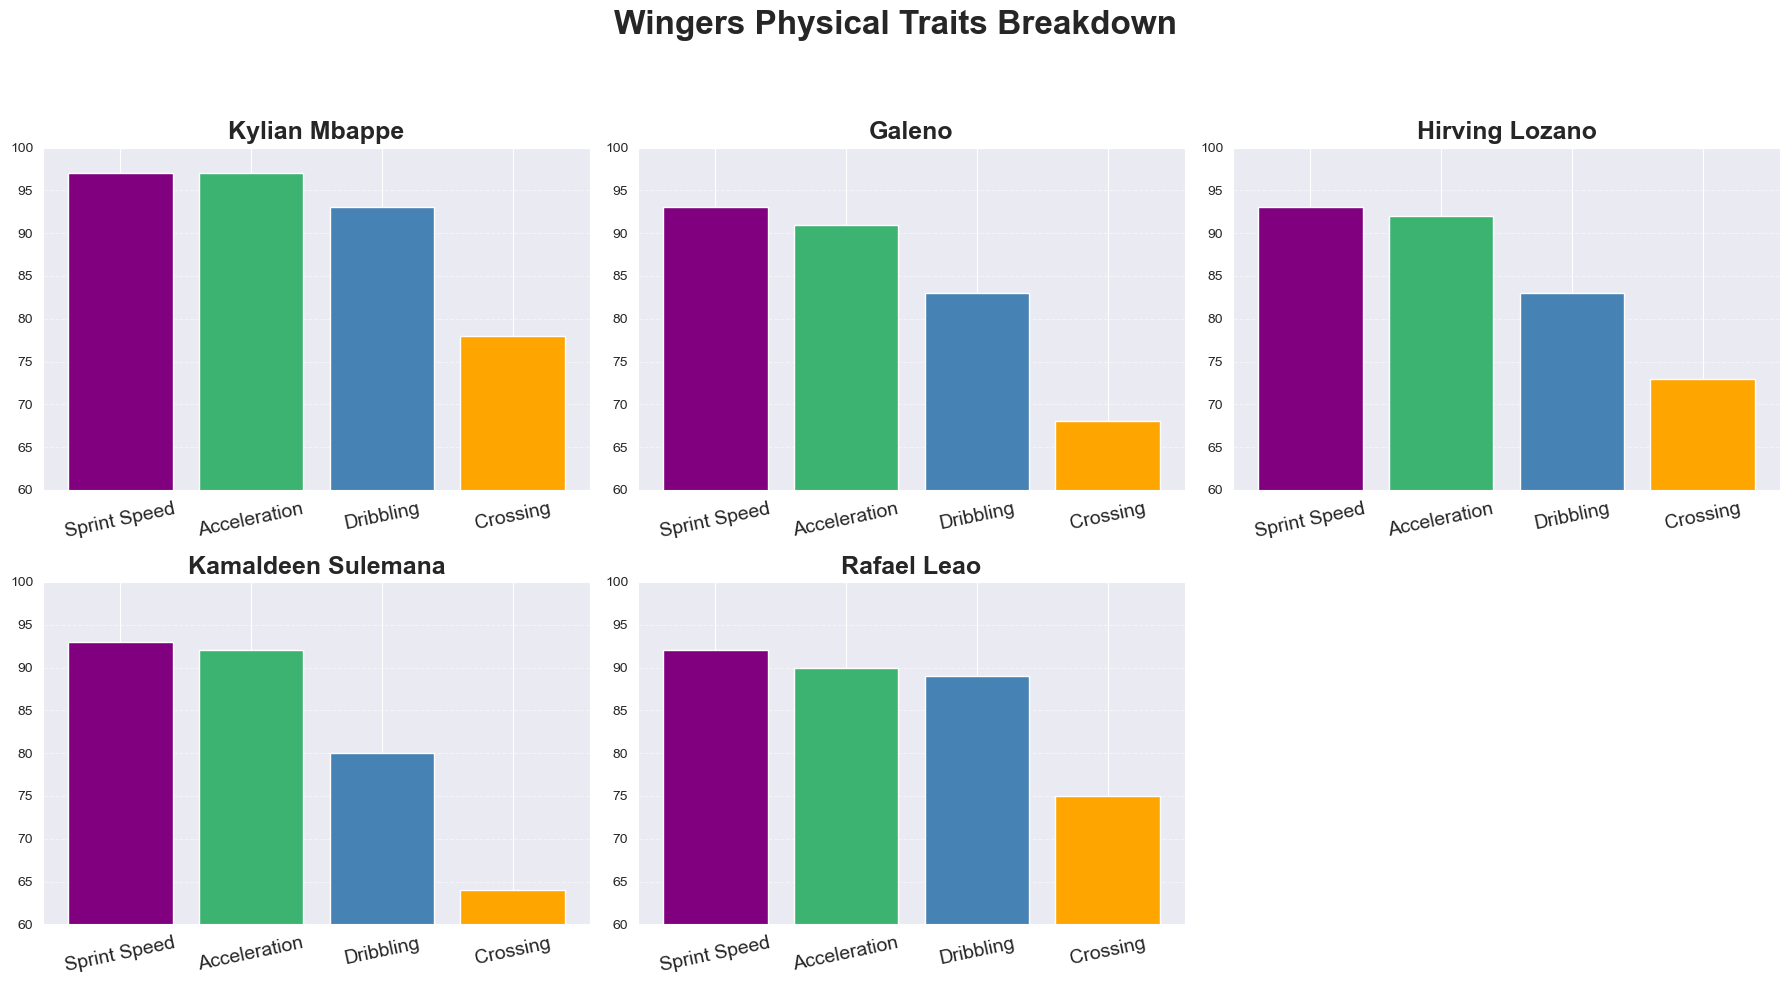

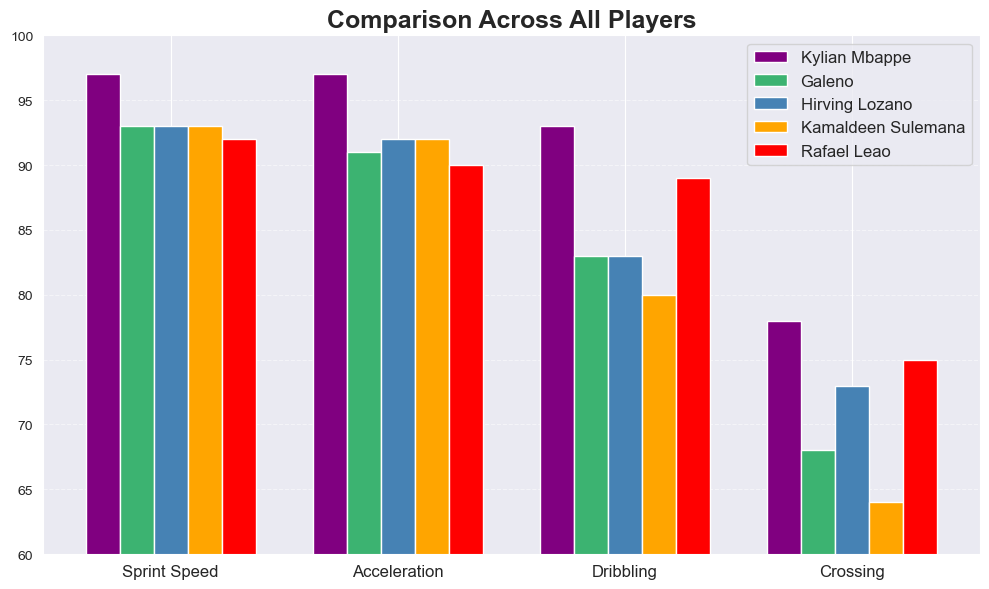

In [131]:
players = {
    'Kylian Mbappe': [97, 97, 93, 78],
    'Galeno': [93, 91, 83, 68],
    'Hirving Lozano': [93, 92, 83, 73],
    'Kamaldeen Sulemana': [93, 92, 80, 64],
    'Rafael Leao': [92, 90, 89, 75]
}

attributes = ['Sprint Speed', 'Acceleration', 'Dribbling', 'Crossing']
player_names = list(players.keys())
data = np.array(list(players.values()))

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Wingers Physical Traits Breakdown', fontsize=24, fontweight='bold')

axs = axs.flatten()

for i, (player, stats) in enumerate(players.items()):
    axs[i].bar(attributes, stats, color=['purple', 'mediumseagreen', 'steelblue', 'orange'])
    axs[i].set_ylim(60, 100)
    axs[i].set_title(player, fontsize=18, fontweight='bold')
    axs[i].set_xticks(range(len(attributes)))
    axs[i].set_xticklabels(attributes, fontsize=14, rotation=12)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(players), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['purple', 'mediumseagreen', 'steelblue', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i, player in enumerate(player_names):
    ax.bar(x + i*width, data[i], width, label=player, color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=12)
ax.set_ylim(60, 100)
ax.set_title('Comparison Across All Players', fontsize=18, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Kylian Mbappe showcases elite pace with top sprint speed (97) and acceleration (97), paired with excellent dribbling (93), making him a lethal winger capable of breaking defenses. His crossing (78) complements his pace, allowing him to create goal-scoring opportunities from wide areas. Galeno offers strong physical speed (93) and acceleration (91) with decent dribbling (83) and crossing (68), providing a reliable wide option who can support build-up play.

Hirving Lozano combines excellent sprint (93) and acceleration (92) with solid dribbling (83) and crossing (73), making him a versatile and fast attacking threat capable of stretching defenses. Kamaldeen Sulemana demonstrates high pace (93) and acceleration (92), but slightly lower dribbling (80) and crossing (64), marking him as a speed-focused winger who can penetrate but may need support in the final third. Rafael Leao excels in dribbling (89) and maintains very good sprint (92) and acceleration (90), coupled with competent crossing (75), making him a creative outlet on the flank capable of both finishing and assisting.

Overall, the dataset illustrates two key player profiles: ultra-quick, direct wingers (Kylian Mbappe, Kamaldeen Sulemana, Hirving Lozano) capable of breaking lines with speed, and balanced attackers (Rafael Leao, Galeno) who combine pace with dribbling and crossing to support both goal creation and wide play.

### Young Talents

In [132]:
young_gems = (
    df[
        (df['age'] < 23) & 
        (df['acceleration'] >= 85) &  
        (df['ball_control'] >= 80) &      
        (df['value'] >= 10_000_000)   
    ]
    [[
        'player', 'club', 'age', 
        'acceleration', 'ball_control', 'dribbling',
        'vision', 'value'
    ]]
    .sort_values(['value', 'acceleration'], ascending=[False, False])
)
young_gems

,player,club,age,acceleration,ball_control,dribbling,vision,value
961,Bukayo Saka,Arsenal,21,88,85,88,83,47500000.0
4247,Rodrygo,Real Madrid,22,88,83,84,73,30500000.0
5644,Gabriel Martinelli,Arsenal,22,89,82,88,75,25000000.0
3671,Gonzalo Plata,R. Valladolid CF,22,90,82,82,73,12500000.0
2496,Callum Hudson-Odoi,Leverkusen,22,86,81,82,74,12500000.0


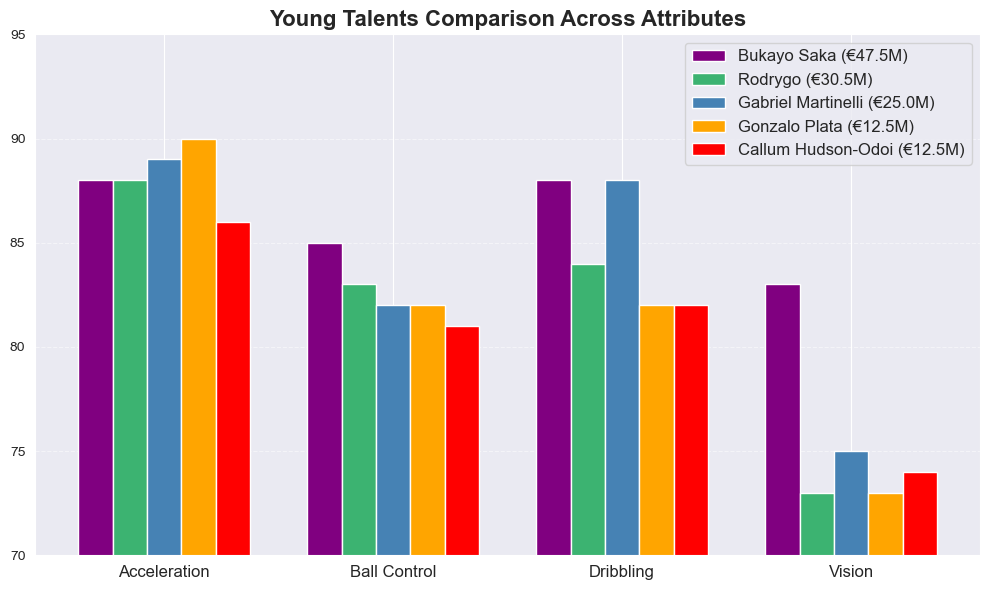

In [133]:
players = {
    'Bukayo Saka': [88, 85, 88, 83],
    'Rodrygo': [88, 83, 84, 73],
    'Gabriel Martinelli': [89, 82, 88, 75],
    'Gonzalo Plata': [90, 82, 82, 73],
    'Callum Hudson-Odoi': [86, 81, 82, 74]
}

values = {
    'Bukayo Saka': 47.5,
    'Rodrygo': 30.5,
    'Gabriel Martinelli': 25.0,
    'Gonzalo Plata': 12.5,
    'Callum Hudson-Odoi': 12.5
}

attributes = ['Acceleration', 'Ball Control', 'Dribbling', 'Vision']

player_names = list(players.keys())
data = np.array(list(players.values()))

x = np.arange(len(attributes))
width = 0.15
colors = ['purple', 'mediumseagreen', 'steelblue', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i, player in enumerate(player_names):
    ax.bar(x + i*width, data[i], width, label=f"{player} (€{values[player]}M)", color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=12)
ax.set_ylim(70, 95)
ax.set_title('Young Talents Comparison Across Attributes', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** Bukayo Saka demonstrates a highly balanced profile with top-tier acceleration (88) and dribbling (88), complemented by strong ball control (85) and vision (83), making him a versatile winger capable of both creating chances and breaking lines. Rodrygo shows similar pace (88) and good dribbling (84), with slightly lower ball control (83) and vision (73), highlighting his direct, speed-focused attacking style.

Gabriel Martinelli excels in dribbling (88) and acceleration (89), paired with solid ball control (82) and vision (75), making him a potent offensive threat on the flank. Gonzalo Plata possesses exceptional acceleration (90) but slightly lower ball control (82), dribbling (82), and vision (73), marking him as a pace-oriented winger ideal for counter-attacks. Callum Hudson-Odoi offers balanced attributes across acceleration (86), dribbling (82), ball control (81), and vision (74), allowing him to contribute effectively in both build-up play and final-third actions.

Overall, the dataset highlights two key player profiles: ultra-quick, direct wingers (Bukayo Saka, Gonzalo Plata, Gabriel Martinelli) who can stretch defenses, and balanced creative attackers (Rodrygo, Callum Hudson-Odoi) who combine pace with ball control and vision to influence both attack and build-up play.

### Set-Piece Wizards

In [134]:
set_piece_masters = (
    df[
        (df['fk_acc'] >= 85) &       
        (df['curve'] >= 85) &        
        (df['long_pass'] >= 80) &    
        (df['vision'] >= 80)         
    ]
    [[
        'player', 'club', 'age',
        'fk_acc', 'curve', 'long_pass', 
        'penalties', 'vision'
    ]]
    .sort_values(['fk_acc', 'curve'], ascending=[False, False])
).head(5)
set_piece_masters

,player,club,age,fk_acc,curve,long_pass,penalties,vision
3239,James Ward-Prowse,Southampton,28,94,93,84,77,82
3555,Lionel Messi,Paris SG,36,93,93,90,75,94
949,Parejo,Villarreal CF,34,90,88,90,88,90
3628,Angel Di Maria,Juventus,35,88,92,81,73,89
5677,Neymar Jr,Paris SG,31,87,88,81,91,90


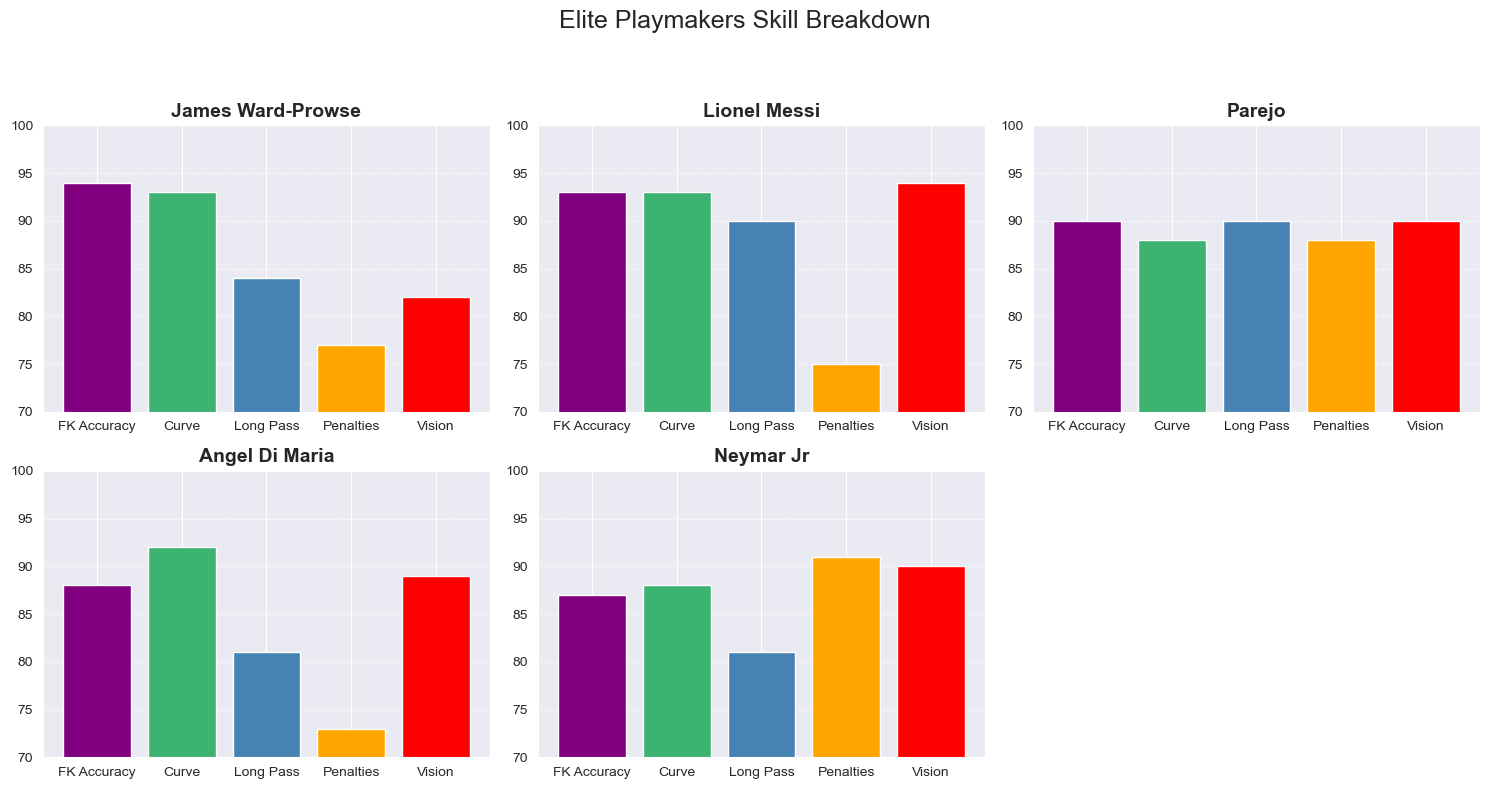

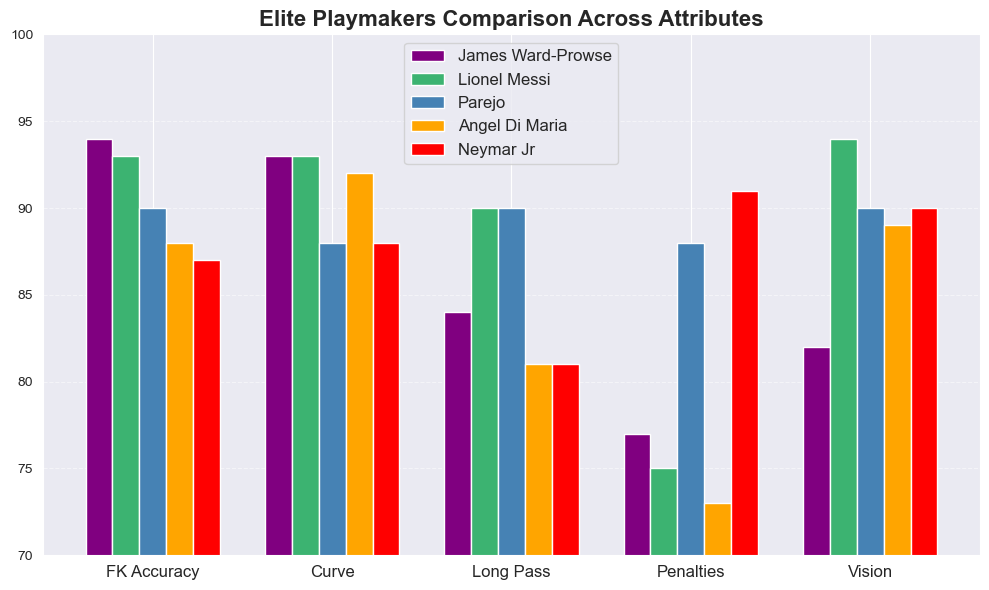

In [135]:
players = {
    'James Ward-Prowse': [94, 93, 84, 77, 82],
    'Lionel Messi': [93, 93, 90, 75, 94],
    'Parejo': [90, 88, 90, 88, 90],
    'Angel Di Maria': [88, 92, 81, 73, 89],
    'Neymar Jr': [87, 88, 81, 91, 90],
}

attributes = ['FK Accuracy', 'Curve', 'Long Pass', 'Penalties', 'Vision']

player_names = list(players.keys())
data = np.array(list(players.values()))

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
fig.suptitle('Elite Playmakers Skill Breakdown', fontsize=18)
for i, (player, stats) in enumerate(players.items()):
    axs[i].bar(attributes, stats, color=['purple', 'mediumseagreen', 'steelblue', 'orange','red'])
    axs[i].set_ylim(70, 100)
    axs[i].set_title(player, fontsize=14, fontweight='bold')
    axs[i].grid(True, axis='y', linestyle='--', alpha=0.7)

for j in range(len(players), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['purple', 'mediumseagreen', 'steelblue', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i, player in enumerate(player_names):
    ax.bar(x + i*width, data[i], width, label=player, color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=12)
ax.set_ylim(70, 100)
ax.set_title('Elite Playmakers Comparison Across Attributes', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** James Ward-Prowse excels in set-piece precision, leading in FK Accuracy (94) and Curve (93), with strong Long Pass (84), Vision (82), and Penalties (77), making him a reliable midfield orchestrator. Lionel Messi showcases elite playmaking with outstanding Vision (94) and strong FK Accuracy (93) and Curve (93), complemented by excellent Long Pass (90), making him a versatile creative force.  

Parejo presents a consistent and well-rounded skill set with balanced FK Accuracy (90), Curve (88), Long Pass (90), Penalties (88), and Vision (90), ideal for controlling midfield tempo. Angel Di Maria combines high Curve (92) with solid Vision (89) and FK Accuracy (88), offering both creative passing and scoring threat. Neymar Jr contributes explosive creativity with strong Penalties (91) and Vision (90), supported by balanced FK Accuracy (87), Curve (88), and Long Pass (81).  

Overall, the dataset highlights two key profiles: set-piece specialists (Ward-Prowse, Parejo) and versatile creative forwards (Messi, Neymar Jr, Di Maria) who can influence games both in open play and from dead-ball situations.

### Complete Players

In [136]:
complete_players = (
    df[
        (
            (df[['ball_control','dribbling','short_pass','stand_tackle','strength','stamina']] > 75)
            .sum(axis=1) >= 5
        ) &
        (df['value'] < 20_000_000)
    ]
    [[
        'player', 'club', 'age', 'value',
        'ball_control', 'dribbling', 'short_pass',
        'stand_tackle', 'strength', 'stamina'
    ]]
    .sort_values(['value', 'age'], ascending=[True, True])
    .head(5)
)
complete_players

,player,club,age,value,ball_control,dribbling,short_pass,stand_tackle,strength,stamina
695,Quinten Timber,Feyenoord,22,4900000.0,78,81,76,73,79,81
434,Jesus Navas,Sevilla FC,37,5500000.0,82,80,81,77,37,78
1251,Jacob Ramsey,Aston Villa,22,6500000.0,78,81,77,73,78,79
2307,Grischa Promel,TSG Hoffenheim,28,8000000.0,76,74,76,76,76,93
5598,Tonny Vilhena,Salernitana,28,8000000.0,78,76,78,72,76,79


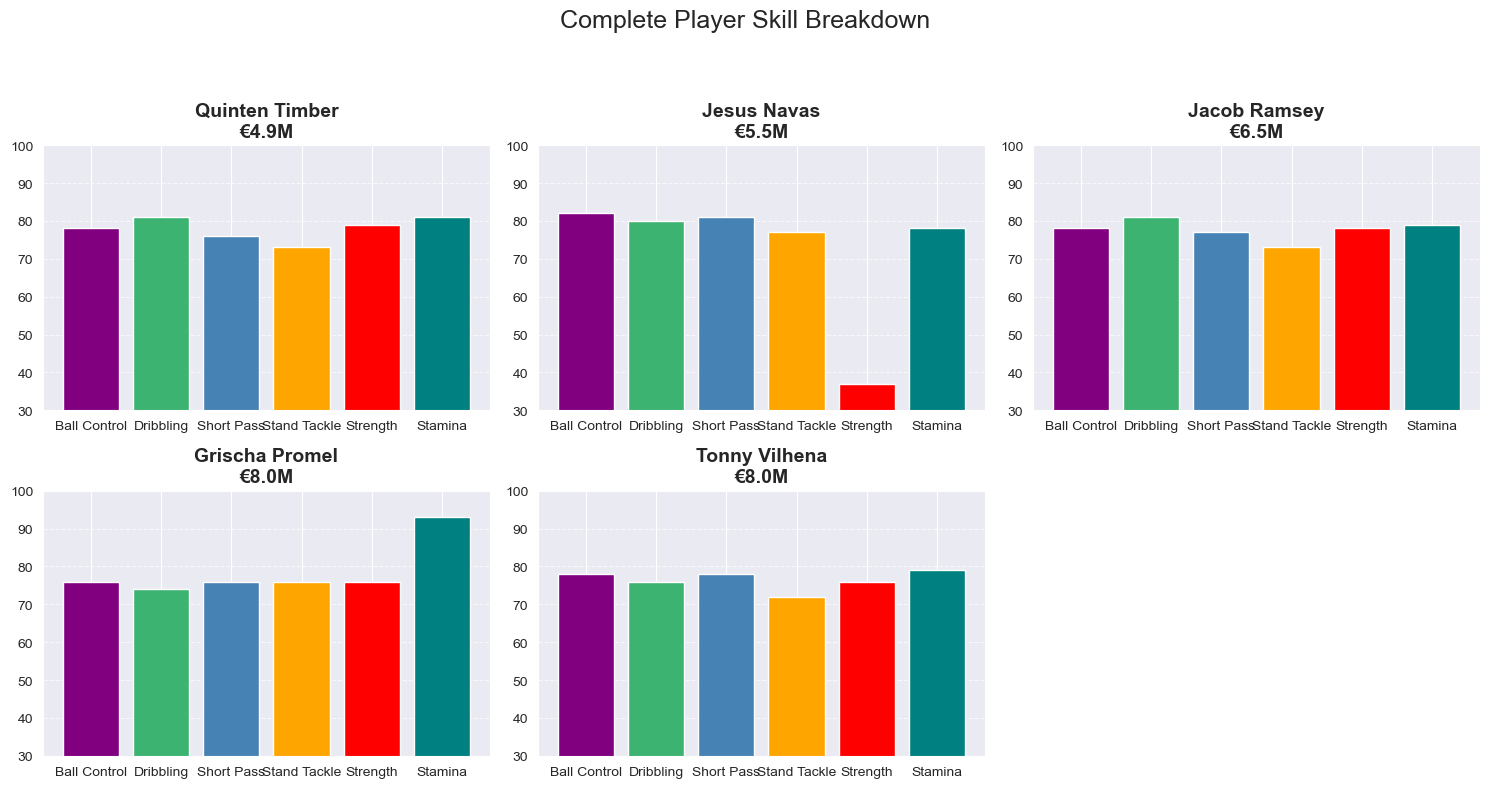

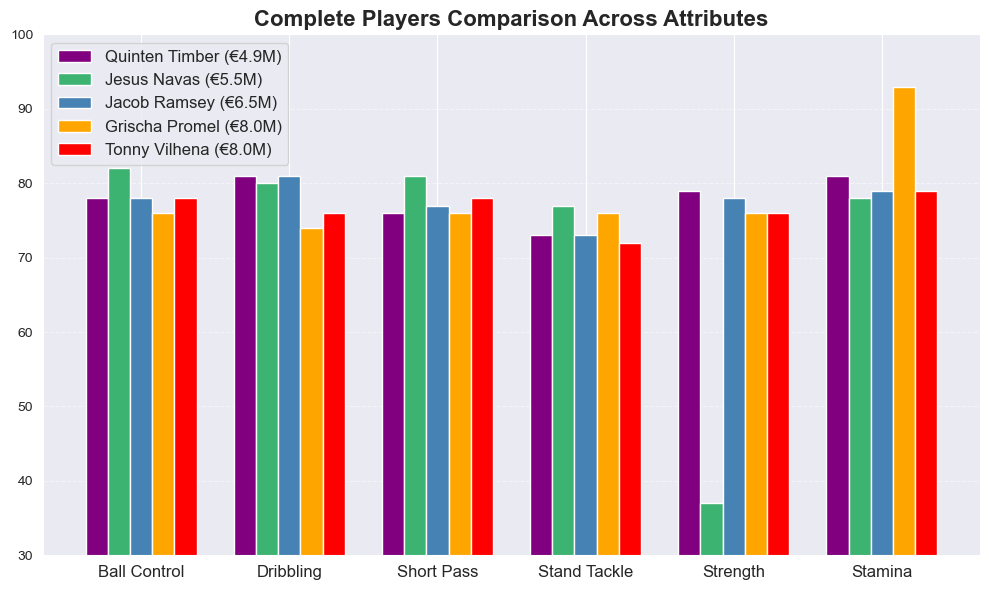

In [137]:
players = {
    'Quinten Timber': [78, 81, 76, 73, 79, 81],
    'Jesus Navas': [82, 80, 81, 77, 37, 78],
    'Jacob Ramsey': [78, 81, 77, 73, 78, 79],
    'Grischa Promel': [76, 74, 76, 76, 76, 93],
    'Tonny Vilhena': [78, 76, 78, 72, 76, 79]
}

values = {
    'Quinten Timber': 4.9,
    'Jesus Navas': 5.5,
    'Jacob Ramsey': 6.5,
    'Grischa Promel': 8.0,
    'Tonny Vilhena': 8.0
}

attributes = ['Ball Control', 'Dribbling', 'Short Pass', 'Stand Tackle', 'Strength', 'Stamina']

player_names = list(players.keys())
data = np.array(list(players.values()))

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
fig.suptitle('Complete Player Skill Breakdown', fontsize=18)

for i, (player, stats) in enumerate(players.items()):
    axs[i].bar(attributes, stats, color=['purple', 'mediumseagreen', 'steelblue', 'orange', 'red', 'teal'])
    axs[i].set_ylim(30, 100)
    axs[i].set_title(f"{player}\n€{values[player]}M", fontsize=14, fontweight='bold')
    axs[i].grid(True, axis='y', linestyle='--', alpha=0.7)

for j in range(len(players), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

x = np.arange(len(attributes))
width = 0.15
colors = ['purple', 'mediumseagreen', 'steelblue', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for i, player in enumerate(player_names):
    ax.bar(x + i*width, data[i], width, label=f"{player} (€{values[player]}M)", color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(attributes, fontsize=12)
ax.set_ylim(30, 100)
ax.set_title('Complete Players Comparison Across Attributes', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:**  
Quinten Timber and Jacob Ramsey showcase well-rounded midfield capabilities with strong ball control (78), dribbling (81), and passing (76–77), coupled with solid tackling (73) and strength (78–79), making them reliable young midfielders with high stamina. Tonny Vilhena and Grischa Promel demonstrate durability and consistency, particularly with high stamina (79–93) and balanced defensive stats, offering stability in central roles.  

Jesus Navas stands out as an experienced veteran, excelling in ball control (82) and passing (81), but lower strength (37) highlights a decline in physical presence, emphasizing his role as a technically gifted playmaker rather than a physical contributor.  

Overall, the dataset illustrates a mix of **young, versatile midfielders** and **experienced technical players**, allowing a team to balance energy, durability, and tactical intelligence in the midfield.

## Correlation Heatmap

A correlation heatmap shows the strength and direction of relationships between 
numerical variables. Values range from **-1 to 1**:

- **Close to 1** — strong positive relationship (both increase together)
- **Close to -1** — strong negative relationship (one increases as other decreases)  
- **Close to 0** — no meaningful relationship

This helps us quickly spot which player attributes are closely linked and which 
are independent of each other.

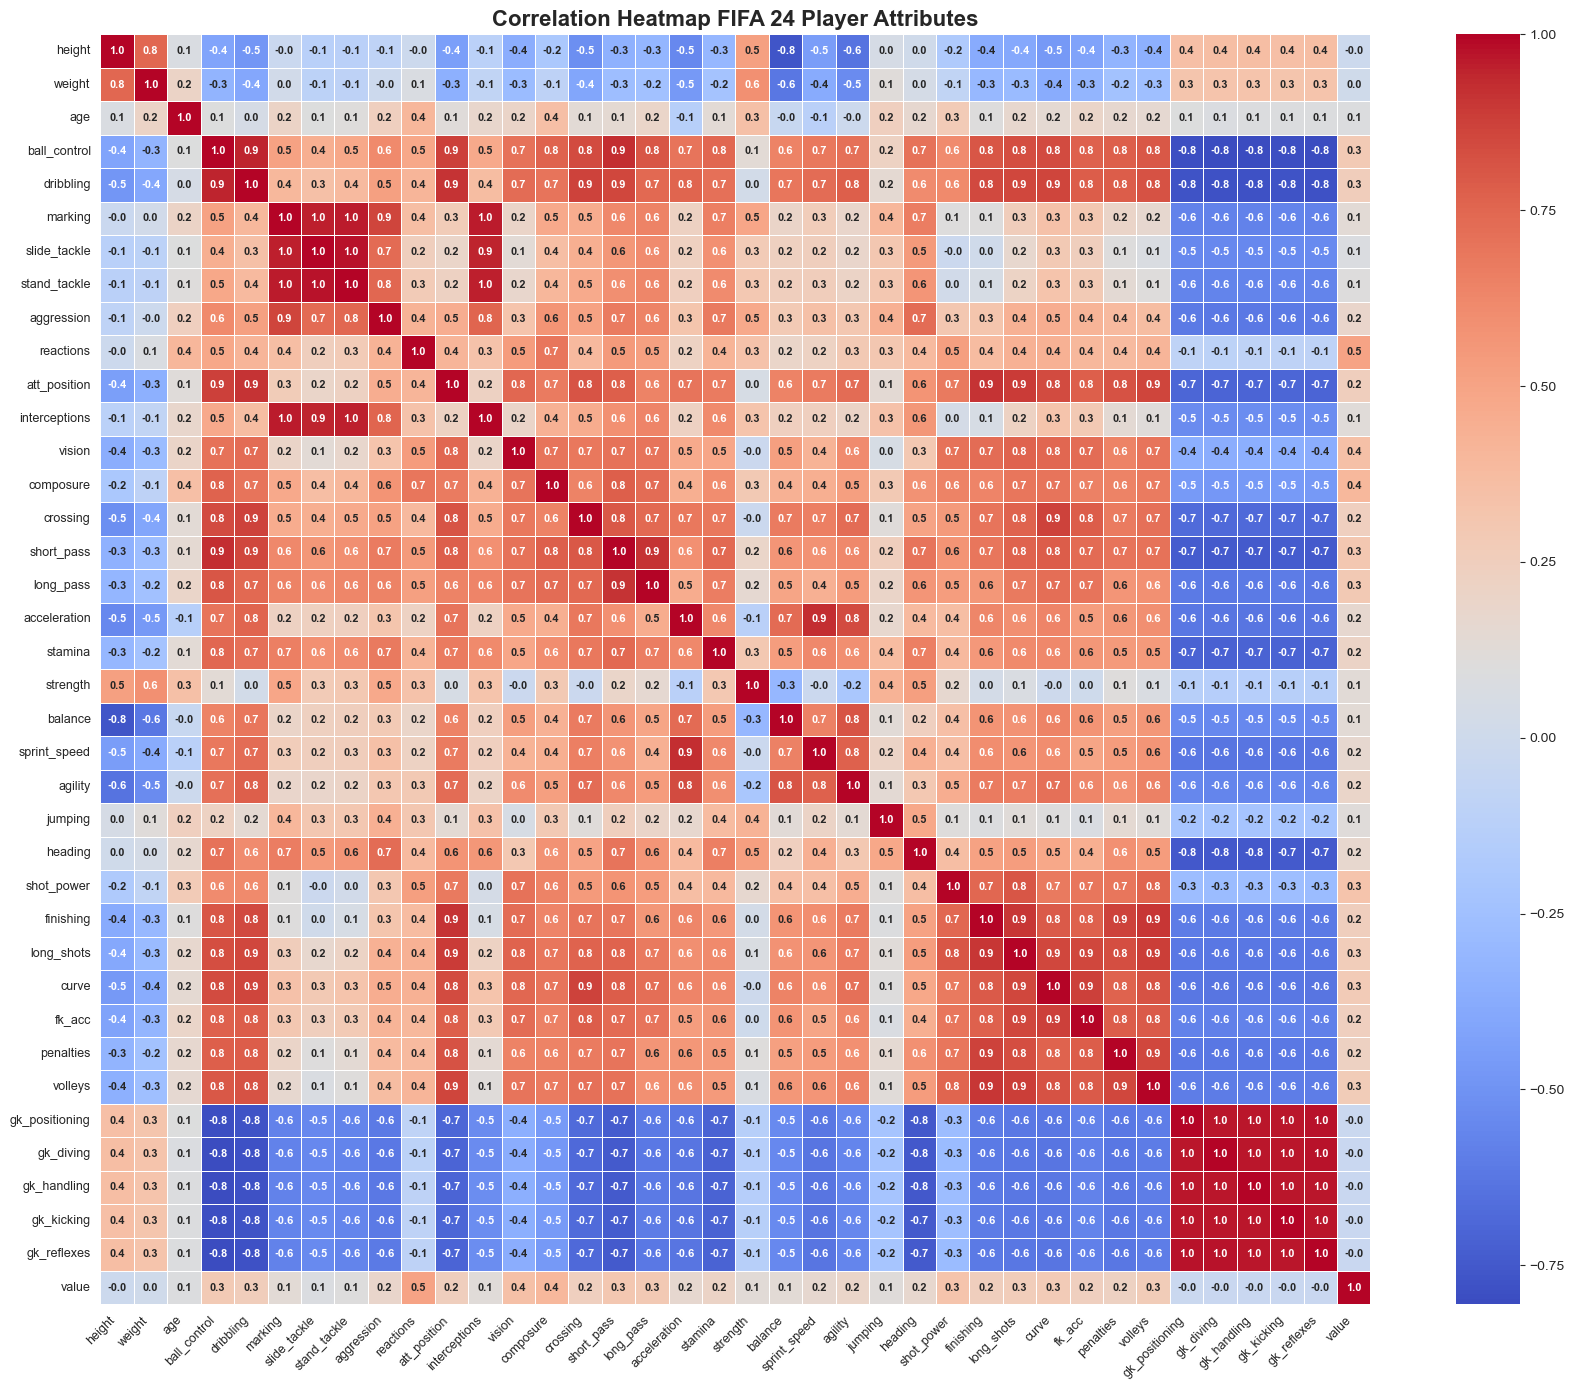

In [138]:
numeric_df = df.drop(columns=['player', 'country', 'club'])

corr_matrix = numeric_df.corr()


plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    annot_kws={'fontsize': 8, 'fontweight': 'bold'},
    square=True,
    fmt='.1f',
    linewidths=0.5
)
plt.title('Correlation Heatmap FIFA 24 Player Attributes', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Bivariate Analysis

In this section we explore relationships between two variables at a time — 
categorical vs numerical and numerical vs numerical — to uncover deeper patterns 
in the data.

Given the large number of columns in this dataset, we focused on the most 
meaningful combinations rather than plotting everything. Additional relationships 
can always be explored based on specific analytical needs.

## Categorical Vs Numerical 

### Countries Producing U18 Players (Top 10)

In [165]:
young_players = df[df['age'] <= 21]
country_avg_value = young_players.groupby('country')['value'].mean().reset_index()

# Only include countries with at least 5 U21 players
country_counts = young_players.groupby('country')['value'].count().reset_index()
country_counts.columns = ['country', 'count']
country_avg_value = country_avg_value.merge(country_counts, on='country')
country_avg_value = country_avg_value[country_avg_value['count'] >= 5]

top_10_countries = country_avg_value.sort_values(by='value', ascending=False).head(10)
top_10_countries[['country', 'value']]

,country,value
70,Spain,1.546133e+06
8,Brazil,1.420222e+06
50,Netherlands,9.032966e+05
24,France,9.018549e+05
59,Portugal,8.940450e+05
77,United States,8.372254e+05
28,Ghana,8.003219e+05
2,Argentina,7.728032e+05
22,England,5.414676e+05
5,Belgium,4.771648e+05


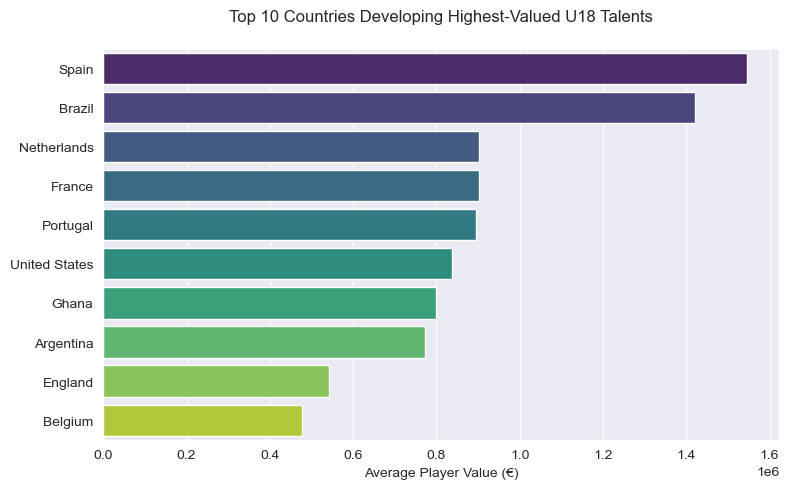

In [166]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Countries Developing Highest-Valued U18 Talents", pad=20)
sns.barplot(data=top_10_countries, x='value', y='country', hue='country', palette='viridis', legend=False)
plt.xlabel("Average Player Value (€)")
plt.ylabel("")  
plt.tight_layout()
plt.show()

**Insight:** Spain and Brazil lead in producing the highest-valued U21 talents, 
reflecting their world-renowned youth development systems — La Masia for Spain 
and Brazil's talent-rich football culture. The Netherlands and France follow 
closely, known for their structured academies like Ajax and Clairefontaine. 
The presence of the United States and Ghana highlights the growing global 
spread of elite young talent beyond traditional football powerhouses.

### Most Valued Club (Top 10)

In [141]:
club_value = df.groupby('club')['value'].sum().reset_index()
top_club = club_value.sort_values(by='value',ascending=False).head(10)
top_club

,club,value
394,Manchester City,427000335.0
209,FC Bayern München,409500430.0
453,Paris SG,400601250.0
395,Manchester Utd,330800275.0
383,Liverpool,313902885.0
58,Arsenal,273603355.0
100,Brazil,215000000.0
138,Chelsea,213500600.0
67,Atlético de Madrid,197502500.0
207,FC Barcelona,186201450.0


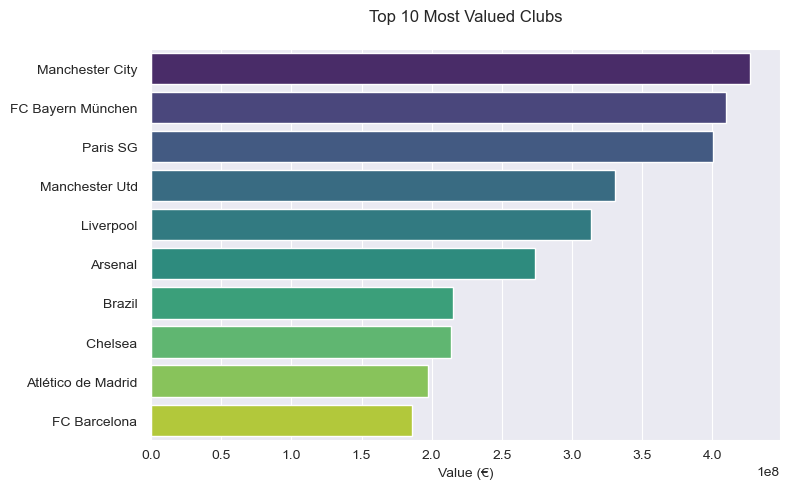

In [167]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Most Valued Clubs", pad=20)
sns.barplot(data=top_club, x='value', y='club', hue='club', palette='viridis', legend=False)
plt.xlabel("Value (€)")
plt.ylabel("") 
plt.tight_layout()
plt.show()

**Insight:** Manchester City leads as the highest valued club with a total squad 
value of over €427M, followed closely by Bayern Munich and Paris Saint-Germain. 
The top 10 is dominated by European giants — Premier League, Bundesliga, and 
Ligue 1 clubs — reflecting the concentration of elite talent in Europe's top leagues.

Notably Brazil appears in the list as a national team, suggesting some players 
are registered under their national team rather than a club in this dataset — 
a minor data inconsistency worth flagging.

### Most Valued Players (Top 10)

In [143]:
highest_paid = df[['player','value']].sort_values(by='value',ascending=False).head(10)
highest_paid

,player,value
5229,Kylian Mbappe,153500000.0
1965,Erling Haaland,123000000.0
4849,Kevin De Bruyne,107500000.0
916,Sadio Mane,101000000.0
5677,Neymar Jr,99500000.0
5676,Mohamed Salah,99500000.0
5136,Joshua Kimmich,97000000.0
4211,Virgil van Dijk,84500000.0
3416,Lautaro Martinez,79500000.0
2458,Gianluigi Donnarumma,78000000.0


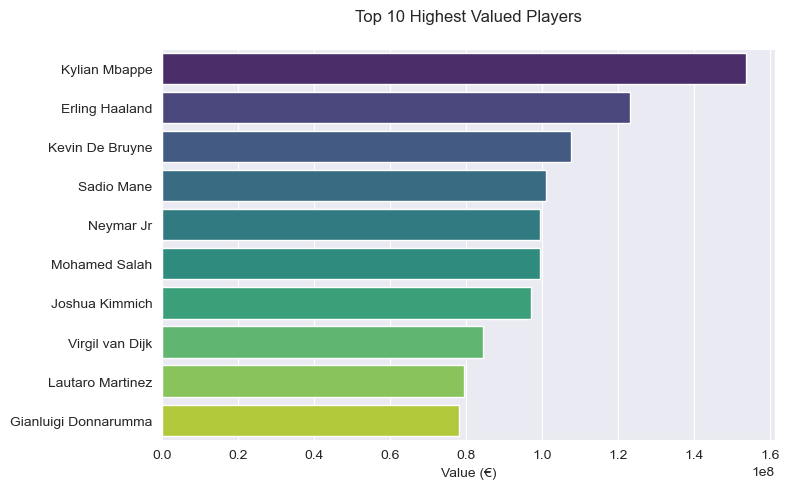

In [168]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Highest Valued Players", pad=20)
sns.barplot(data=highest_paid, x='value', y='player', hue='player', palette='viridis', legend=False)
plt.xlabel("Value (€)")
plt.ylabel("")  
plt.tight_layout()
plt.show()

**Insight:** Kylian Mbappe leads as the highest valued player at €153.5M, followed 
by Erling Haaland at €123M and Kevin De Bruyne at €107.5M. The list is dominated 
by forwards and midfielders, reflecting how attacking and creative players command 
the highest market values in modern football.

Notably Virgil van Dijk and Gianluigi Donnarumma are the only defender and 
goalkeeper in the top 10, highlighting that elite defensive players can match 
attackers in market value — though they remain exceptions rather than the norm.

### Oldest player (Top 10)

most players in football/soccer are considered old when you reach 30s so we'll use >=30 condition to filter out top 10 oldest players 

In [145]:
filter_old = df[df['age'] >= 30]
old_players = filter_old.sort_values(by='age', ascending=False).head(10)
old_players[['player', 'age']]

,player,age
4361,Thomas Mikkelsen,40
3143,Sebastian Viera,40
5038,Yeom Ki Hun,40
4002,Alessandro Diamanti,40
4282,Claudio Bravo,40
1796,Federico Marchetti,40
3785,Mariano Andujar,40
2454,Milenko Fierro,39
5291,Paolo Guerrero,39
5467,Samir Handanovic,39


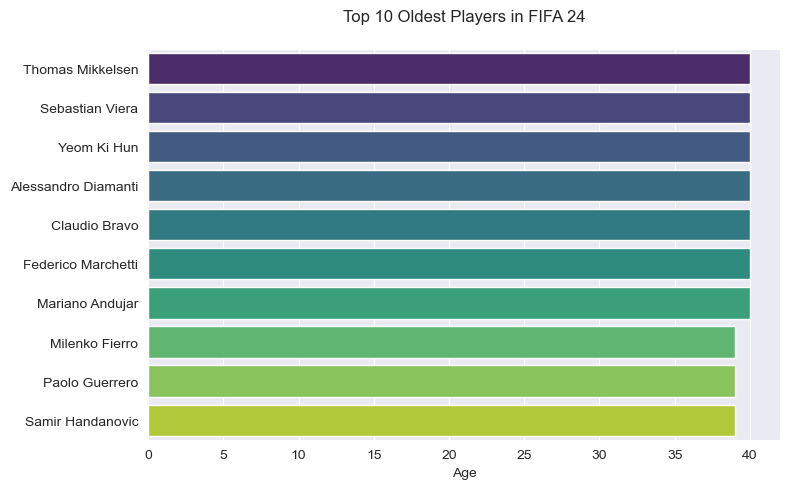

In [169]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Oldest Players in FIFA 24", pad=20)
sns.barplot(data=old_players, x='age', y='player', hue='player', palette='viridis', legend=False)
plt.xlabel("Age")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Insight:** The oldest players in FIFA 24 are clustered around age 39–40, with 
Thomas Mikkelsen, Sebastian Viera and Yeom Ki Hun topping the list. Notably the 
group includes goalkeepers like Claudio Bravo, Federico Marchetti and Samir 
Handanovic — reflecting the well-known trend that goalkeepers tend to have longer 
careers than outfield players due to lower physical demands on their bodies.

### player with highest finishing rate (Top 10)

In [146]:
finish = df[df['finishing']>85]
top_finish = finish.sort_values(by='finishing',ascending=False).head(10)
top_finish[['player','finishing']]

,player,finishing
1965,Erling Haaland,94
5229,Kylian Mbappe,93
5675,Karim Benzema,92
5676,Mohamed Salah,92
5678,Cristiano Ronaldo,91
3555,Lionel Messi,90
4498,Iago Aspas,90
329,Gerard Moreno,89
857,Romelu Lukaku,88
3416,Lautaro Martinez,88


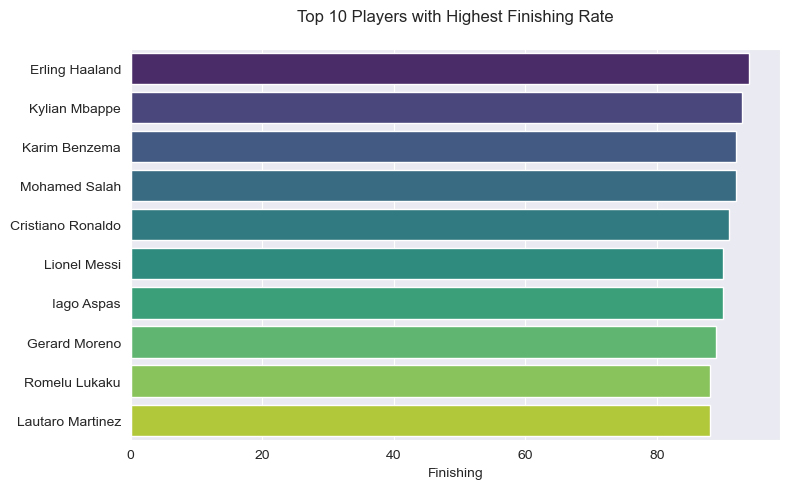

In [170]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Players with Highest Finishing Rate", pad=20)
sns.barplot(data=top_finish, x='finishing', y='player', hue='player', palette='viridis', legend=False)
plt.xlabel("Finishing")
plt.ylabel("")  
plt.tight_layout()
plt.show()

**Insight:** Erling Haaland leads with the highest finishing rating (94), followed 
by Kylian Mbappe (93) and Karim Benzema (92) — reflecting their clinical efficiency 
in front of goal. The list is dominated by elite strikers and forwards, confirming 
that high finishing is a defining trait of the world's best attackers.

Notably Lionel Messi appears at 90 despite not being a traditional striker, 
highlighting his exceptional goalscoring ability beyond his primary creative role. 
Iago Aspas and Gerard Moreno represent the hidden gems of the list — less globally 
renowned but statistically among the most clinical finishers in the game.

### player with highest strength (Top 10)

In [148]:
strength = df[df['strength']>85]
top_strength = strength.sort_values(by='strength',ascending=False).head(10)
top_strength[['player','strength']]

,player,strength
857,Romelu Lukaku,95
4211,Virgil van Dijk,93
1965,Erling Haaland,93
39,Kalidou Koulibaly,93
718,Christian Luyindama,93
3407,Pedrao Tofico,93
607,Sebastian Mai,93
4314,Hendrik Weydandt,92
1193,Garrido,92
3281,Jamille Matt,92


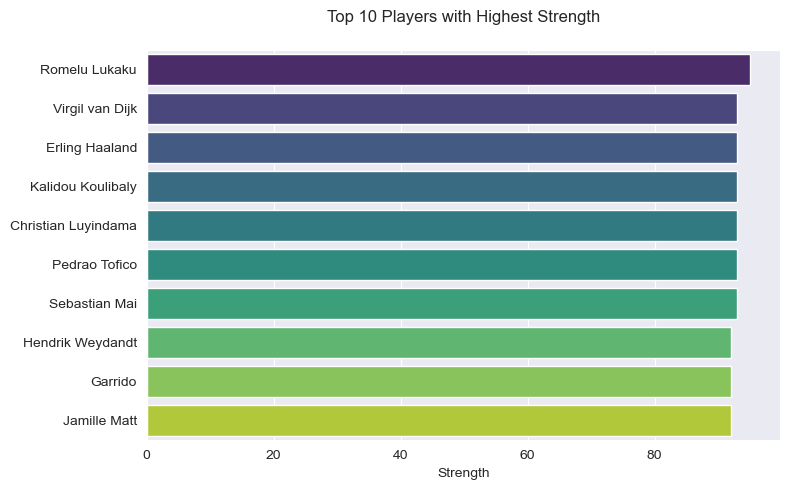

In [171]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Players with Highest Strength", pad=20)
sns.barplot(data=top_strength, x='strength', y='player', hue='player', palette='viridis', legend=False)
plt.xlabel("Strength")
plt.ylabel("")  
plt.tight_layout()
plt.show()

**Insight:** Romelu Lukaku leads with the highest strength rating (95), followed 
by Virgil van Dijk and Erling Haaland both at 93 — reflecting their imposing 
physical presence on the pitch. Kalidou Koulibaly and Christian Luyindama 
represent elite defensive strength, confirming that center-backs dominate 
this category.

Notably the list includes several lesser-known players like Sebastian Mai, 
Hendrik Weydandt and Jamille Matt alongside global stars — suggesting that 
raw physical strength is distributed across leagues and not exclusive to 
top-tier clubs.

## Numerical vs Numerical 

### Height -- Weight 

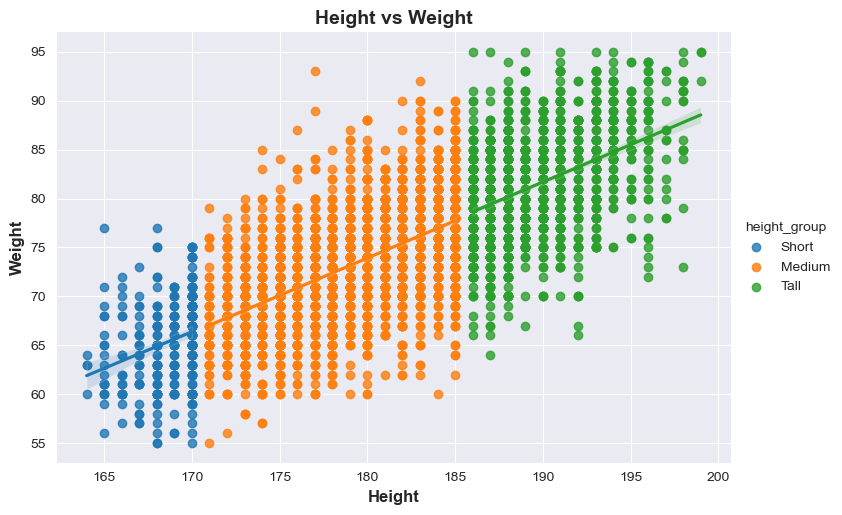

In [172]:
df['height_group'] = pd.cut(df['height'], bins=[150, 170, 185, 205], labels=['Short', 'Medium', 'Tall'])

sns.set_style('darkgrid')
sns.lmplot(data=df, x='height', y='weight', hue='height_group', height=5, aspect=1.5)
plt.title("Height vs Weight",fontsize=14,fontweight='bold')
plt.xlabel("Height",fontsize=12,fontweight='bold')
plt.ylabel("Weight",fontsize=12,fontweight='bold')
plt.show()

**Insight:** There is a clear positive correlation between height and weight across 
all three player groups — taller players consistently weigh more. Short players 
cluster around 60–75kg while tall players range from 75–95kg, reflecting natural 
body proportion patterns. The trend lines for all three groups run parallel, 
suggesting the height-weight relationship is consistent regardless of which 
group a player falls into.

### age -- value

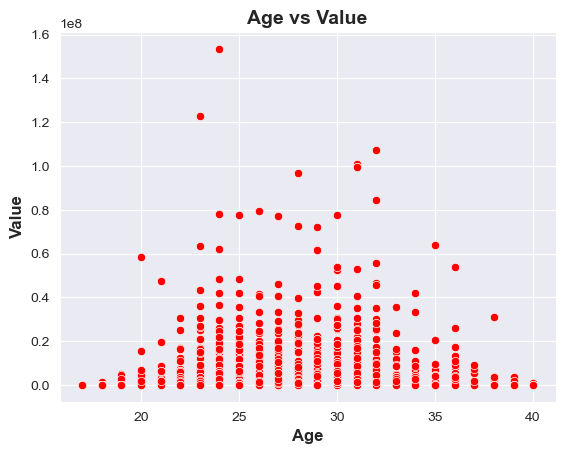

In [174]:
sns.set_style('darkgrid')
sns.scatterplot(data=df, x='age', y='value',color='red')
plt.title("Age vs Value",fontsize=14,fontweight='bold')
plt.xlabel("Age",fontsize=12,fontweight='bold')
plt.ylabel("Value",fontsize=12,fontweight='bold')
plt.show()

**Insight:** Player market value peaks in the mid-to-late 20s, typically between 
ages 24–28, before declining sharply as players approach their 30s. Young players 
under 22 show relatively low values despite their potential, while the highest 
valued players cluster around peak athletic age.

The chart also reveals a wide value spread at every age — confirming that age 
alone does not determine value. Factors like skill, position, and club affiliation 
play a significant role alongside age in determining a player's market worth.

### dribbling -- ball control

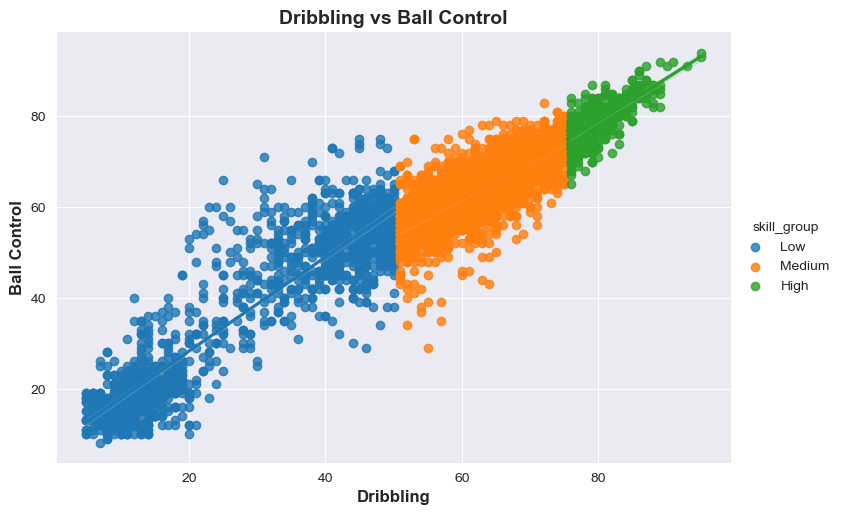

In [175]:
df['skill_group'] = pd.cut(df['dribbling'], bins=[0, 50, 75, 100], labels=['Low', 'Medium', 'High'])

sns.set_style('darkgrid')
sns.lmplot(data=df,x='dribbling',y='ball_control',hue='skill_group',height=5,aspect=1.5)
plt.title("Dribbling vs Ball Control", fontsize=14, fontweight='bold')
plt.xlabel("Dribbling", fontsize=12, fontweight='bold')
plt.ylabel("Ball Control", fontsize=12, fontweight='bold')
plt.show()

**Insight:** There is a strong positive correlation between dribbling and ball 
control across all skill groups — players who dribble well consistently show 
high ball control too. This makes intuitive sense as both skills are fundamentally 
linked to a player's technical ability on the ball.

The High skill group shows the tightest cluster at the top right, confirming 
that elite dribblers are almost always elite ball controllers. The Low group 
— predominantly goalkeepers — shows more scatter, reflecting that GK attributes 
are independent of outfield technical skills.

### vision -- short pass

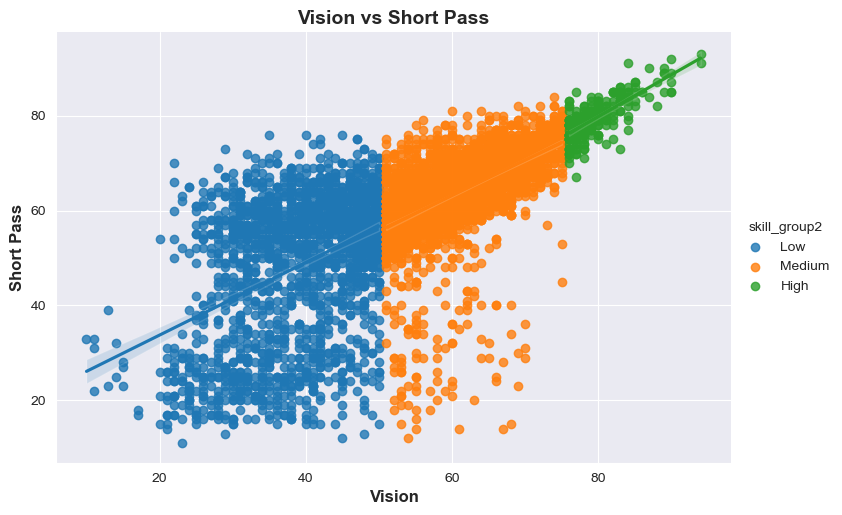

In [176]:
df['skill_group2'] = pd.cut(df['vision'], bins=[0, 50, 75, 100], labels=['Low', 'Medium', 'High'])

sns.set_style('darkgrid')
sns.lmplot(data=df,x='vision',y='short_pass',hue='skill_group2',height=5,aspect=1.5)
plt.title("Vision vs Short Pass", fontsize=14, fontweight='bold')
plt.xlabel("Vision", fontsize=12, fontweight='bold')
plt.ylabel("Short Pass", fontsize=12, fontweight='bold')
plt.show()

**Insight:** Vision and short passing show a strong positive correlation across 
all skill groups — players with high vision consistently deliver better short 
passes. This reflects the natural connection between reading the game and 
executing passes effectively.

The High group clusters tightly in the top right confirming that elite 
playmakers combine both attributes seamlessly. The Low group again shows 
wider scatter — predominantly goalkeepers whose vision and passing ratings 
are independent of their actual goalkeeping ability.

### sprint speed -- acceleration

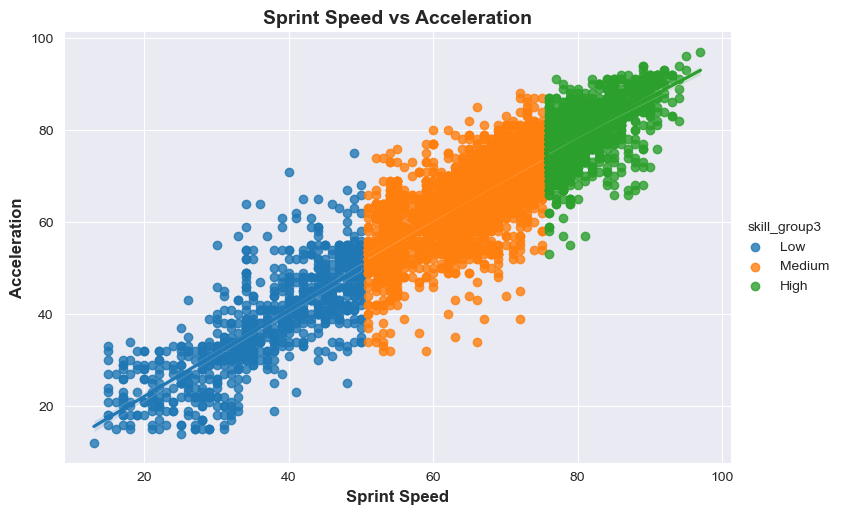

In [177]:
df['skill_group3'] = pd.cut(df['sprint_speed'], bins=[0, 50, 75, 100], labels=['Low', 'Medium', 'High'])

sns.set_style('darkgrid')
sns.lmplot(data=df,x='sprint_speed',y='acceleration',hue='skill_group3',height=5,aspect=1.5)
plt.title("Sprint Speed vs Acceleration", fontsize=14, fontweight='bold')
plt.xlabel("Sprint Speed", fontsize=12, fontweight='bold')
plt.ylabel("Acceleration", fontsize=12, fontweight='bold')
plt.show()

**Insight:** Sprint speed and acceleration show the strongest positive correlation 
of all numerical pairs analyzed — players who are fast almost always accelerate 
quickly too. The High group clusters very tightly, confirming that elite pace 
is a combination of both attributes working together rather than one compensating 
for the other.

This relationship makes physical sense — a player who reaches top speed quickly 
(acceleration) naturally tends to also have a high top speed (sprint speed). 
The Low group scatter again reflects goalkeepers whose pace attributes are 
rated independently of their actual goalkeeping performance.

### heading -- jumping

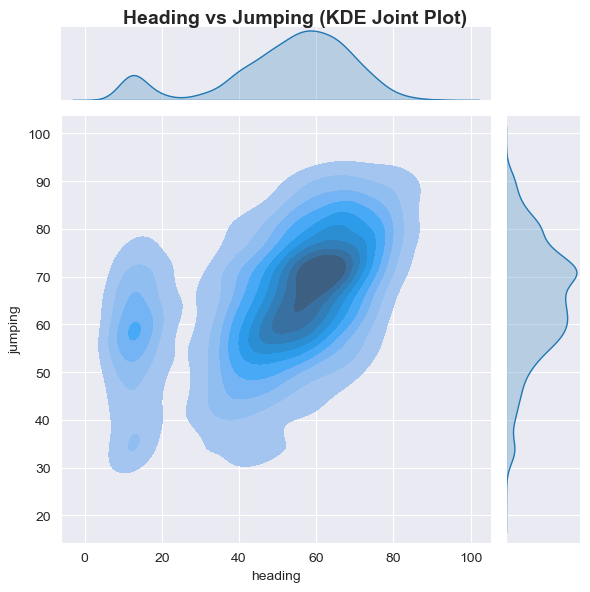

In [178]:
sns.set_style("darkgrid")
sns.jointplot(
    data=df,
    x="heading",
    y="jumping",
    kind="kde",
    fill=True,
    height=6
)
plt.suptitle("Heading vs Jumping (KDE Joint Plot)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.95)  
plt.show()

**Insight:** Heading and jumping show a moderate positive correlation — players 
who jump higher tend to be better at heading the ball, which makes physical sense 
as aerial ability depends heavily on leap height.

The KDE density plot reveals the main cluster sits around heading 55–70 and 
jumping 60–75, representing the average outfield player. The secondary cluster 
at lower values reflects goalkeepers and technically-focused players who are 
not required to win aerial duels. The elongated shape of the density confirms 
the positive relationship between the two attributes.

## Conclusion

This analysis performed a comprehensive exploration of the FIFA 24 Player Statistics 
dataset, covering over 5,000 players across technical, physical, mental, and 
goalkeeper attributes.

**Key Findings:**

- Most FIFA 24 players are young, peaking around age 23–24, with market values 
highest between ages 24–28 before declining sharply after 30.
- England, Germany and Spain dominate player representation, while Spain and Brazil 
lead in producing the highest-valued U21 talents through strong youth academies.
- Manchester City leads club market value, with European giants dominating the 
top 10 — reflecting the concentration of elite talent in Europe's top leagues.
- Kylian Mbappe is the highest valued player at €153.5M, with forwards and 
midfielders commanding the highest market values overall.
- Strong correlations exist between technically linked attributes — dribbling 
and ball control, vision and short pass, sprint speed and acceleration — 
confirming that elite players develop complementary skills together.
- Goalkeepers consistently appear as outliers in outfield skill distributions, 
reinforcing that they are a fundamentally distinct player type in the dataset.
- Romelu Lukaku leads in strength, Erling Haaland in finishing, and the oldest 
players are predominantly goalkeepers — reflecting the position's longevity advantage.

In [179]:
try:
    df_export = df.drop(columns=['height_group', 'skill_group', 'skill_group2', 'skill_group3'])
    df_export.to_csv("Cleaned_FIFA24_PlayerStats.csv", index=False)
    print("Cleaned dataset exported successfully!")
except Exception as e:
    print(f"Export failed: {e}")

Cleaned dataset exported successfully!
